# Preample
Load the necessary packages, modules, scripts, etc...

In [3]:
# Functions
import pysd
import os
import pandas as pd
import numpy as np
import pybalmorel
from pybalmorel import MainResults
from time import time
from tqdm import tqdm
import matplotlib.pyplot as plt

In [4]:
# Internal imports
import python_scripts.plot_functions as sd_plot # Import the plot functions from the plot_functions.py file, which contains functions for plotting results
from python_scripts.result_loading import result_loading_class # Import the result_loading_class from the result_loading.py file, which enables easy access to results from the different models
from python_scripts.data_loading import data_loading_class # Import the data_loading_class from the data_loading.py file, which enables easy access to data from the different data sources
import python_scripts.write_functions as sd_write # Import the write_functions from the write_functions.py file, which contains functions for writing results to files readable by Balmorel
import python_scripts.balmorel_loading as bal_loading # Import the balmorel_loading module, which contains functions for loading Balmorel results
import python_scripts.make_loop as make_loop
import python_scripts.compute_balmorel_distances as compute_balmorel_distances # Import the compute_balmorel_distances module, which contains functions for computing distances between Balmorel results and System Dynamics results

# Pre-work

### Base model
We load a base model, which we will later make changes to

In [5]:

cwd = os.getcwd()
# model_name = "H2Sim_model_2026_altWTPdef"
model_name = "HyADOPTS_w_ETS_penalty"
model_short_path = "vensim_models/" + model_name

model_loaded = False # Set to True if the model is loaded from a Python file # Saves some time when reloading an unchanged version of the model

start = time()
if model_loaded: # Load the model from the Python file
    model_file = os.path.join(cwd, model_short_path + ".py")
    model = pysd.load(model_file)
else: # Read the model from the Vensim mdl file
    model_file = os.path.join(cwd, model_short_path + ".mdl")
    model = pysd.read_vensim(model_file, split_views = True)

print("Model loaded in {} seconds".format(np.round(time()-start,3)))

# Object containing dicts and lists required to easily extract results from the translated vensim model:
rl = result_loading_class()

### ------- Load new data ------- ###
dl = data_loading_class()
# All data is loaded with function calls to the data_loading_class.
# **kwargs can be used for "sensitivity" : float, which scales the data with a factor

# Fossil fuels:
gas_prices      = dl.load_gas_prices()
oil_prices      = dl.load_oil_prices()
coal_prices     = dl.load_coal_prices()

# Biomass:
woodchip_prices = dl.load_woodchip_prices()

# CO2:
carbon_taxes    = dl.load_carbon_taxes(**{"discount_rate": 0.08}) # Discount rate is used to convert future cost flows to present value (basemodel["Discount Rate"])

distribution_keys = dl.load_distribution_keys()
electricity_demand = dl.load_electricity_demand()
hydrogen_data = dl.load_hydrogen_data()

basemodel = model.copy()

### ------- Load data in model - if the original model should be saved use model.copy() to copy the current version of the  ------- ###
basemodel.set_components({"GAS PRICE LOOKUP": gas_prices,
                          "OIL PRICE LOOKUP": oil_prices,
                          "COAL PRICE LOOKUP": coal_prices,
                          "BIOMASS PRICE LOOKUP": woodchip_prices,
                          "CARBON TAX LOOKUP": carbon_taxes,
                          "Green H2 subsidy size": 0,
                          "SLOPE" : 10,
                          "ECONOMIC DECOMMISSIONING": 1,
                          "Hard Regulation": 0,})
time_step = 1/4

Model loaded in 14.298 seconds


c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")


### Run the base model

In [6]:
final_year = 2050
basemodel_results = basemodel.run(final_time=final_year, time_step=time_step) # Run from 2022 to 2050

In [7]:
sd_write.write_hydrogen_demand(model_results=basemodel_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        sub_path='\\loop1'
                                        )

,BE,BG,CZ,DK1,DK2,DE4-E,DE4-N,DE4-S,DE4-W,EE,...,NO3,NO4,NO5,UK,BA,ME,MK,AL,RS,CH
2030,5.003833e+05,188623.807987,3.795283e+05,112707.747927,112198.661189,4.035560e+05,154073.886152,5.248536e+05,1.556978e+06,46773.654433,...,74565.485916,37299.942028,37248.652757,2.288234e+06,75696.538702,17557.448720,44039.152388,39175.031409,145251.729124,2.775801e+05
2040,1.621461e+06,622549.480432,1.245588e+06,369203.400186,348532.602096,1.326431e+06,484558.579078,1.750669e+06,5.035070e+06,147956.857907,...,208193.765650,104794.437078,102702.030900,7.213448e+06,245914.610906,55307.670134,144171.557472,129987.509674,475309.158121,8.834365e+05
2050,2.180457e+06,839880.701881,1.675222e+06,502977.920498,459649.977377,1.789396e+06,641691.646541,2.376787e+06,6.725398e+06,195212.643228,...,279917.543328,141420.890710,137034.754410,9.563463e+06,328574.730662,72468.406913,193542.793827,180121.841812,638510.796774,1.170417e+06


In [8]:
sosibu = sd_write.write_fuel_demand(model_results=basemodel_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        filename="SOSIBUBOUND",
                                        )

dh2 = sd_write.write_hydrogen_demand(model_results=basemodel_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        )

de_trans, de_total = sd_write.write_electricity_demand(model_results=basemodel_results,
                                            distribution_keys=distribution_keys,
                                            electricity_demand=electricity_demand,
                                            model_years=[2030, 2040, 2050],
                                            )

electrolyzer_CAPEX = sd_write.write_electrolyzer_capex(model_results=basemodel_results,
                                                        hydrogen_data=hydrogen_data,
                                                        model_years=[2030, 2040, 2050],
                                                        )
smr_max = sd_write.write_hydrogen_production(model_results=basemodel_results,
                                                        distribution_keys=distribution_keys,
                                                        model_years=[2030, 2040, 2050],
                                                        )

                                                GDTYPE     GDFUEL  GDCV  \
GNR_ELYS_ELEC_AEC                     HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2020               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2030               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2040               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2050               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2020           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2030           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2040           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2050           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_FC_H2_SOFCC                        HYDROGEN_GH2TOE   HYDROGEN   0.0   
GNR_FC_H2_SOFCC_Y-2020                 HYDROGEN_GH2TOE   HYDROGEN   0.0   
GNR_FC_H2_SOFCC_Y-2030                 HYDROGEN_GH2TOE   HYDROGEN   0.0   
GNR_FC_H2_SOFCC_Y-2040   

# Start looping
### Write important results to Balmorel as input
Before being able to assess the impact of hydrogen subsidy, we first need to be sure that we have a proper baseline. It is not sufficient to simply write the results and use them in Balmorel, since we might receive model outputs that alter the the input state of the SD model. This includes power prices and carbon tax in particular. We follow a few steps:
1) Run base SD and get projections of consumption.
2) Write results into Balmorel files and use them as demands for Balmorel to solve. In this step there is also a need to distribute the demands regionally, using distribution keys.
3) Read power prices (as seen by electrolyzers) and carbon prices.
4) Re-run SD model to get a new baseline. Repeat and try to reach a convergence.
Once this phase is over, we have a 'better' baseline that we can use to assess the necessity and impact of hydrogen subsidies.

### Loop 1

In [9]:
loop1_results, loop1_model = make_loop.make_loop(model = basemodel,
                                    gdx_file = 'MainResults_loop1.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '/loop1',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


Loading gdxfiles\MainResults_loop1.gdx


FileNotFoundError: 
Couldnt add file MainResults_loop1.gdx!
Beware of æ,ø,å,ö,ü,ä or other non-english letters in the folders of your absolute path: c:\GitHub\Balmorel_HyADOPTS_couple\gdxfiles.
The GAMS API requires an absolute path with no non-english letters.

### Loop 2

In [8]:
loop2_results, loop2_model = make_loop.make_loop(model = basemodel,
                                    gdx_file = 'MainResults_loop2.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '/loop2',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_loop2.gdx


c:\GitHub\h2_system_dynamics_paper\python_scripts\balmorel_loading.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_consumption_electrolyzer.drop(columns=['Area','Generation','Fuel','Unit','Technology'], inplace=True)
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_loop2.gdx
Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_loop2.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_loop2.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\python_scripts\write_functions.py:562: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  hydrogen_data.fillna('', inplace=True)


### Loop 3

In [132]:
loop3_results, loop3_model = make_loop.make_loop(model = basemodel,
                                    gdx_file = 'MainResults_loop3.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '/loop3',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_loop3.gdx


c:\GitHub\h2_system_dynamics_paper\python_scripts\balmorel_loading.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_consumption_electrolyzer.drop(columns=['Area','Generation','Fuel','Unit','Technology'], inplace=True)
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_loop3.gdx
Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_loop3.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_loop3.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\python_scripts\write_functions.py:562: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  hydrogen_data.fillna('', inplace=True)


### Loop 4

In [10]:
loop4_results, loop4_model = make_loop.make_loop(model = basemodel,
                                    gdx_file = 'MainResults_base.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '\\loop4',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


Loading gdxfiles\MainResults_base.gdx


c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()
c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


Loading gdxfiles\MainResults_base.gdx
Loading gdxfiles\MainResults_base.gdx


c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


Loading gdxfiles\MainResults_base.gdx


c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 76.957332 to 77
  warnings.warn(
c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 76.957332 to 77
  warnings.warn(


Checkpoint 1: Model has run
                                                GDTYPE     GDFUEL  GDCV  \
GNR_ELYS_ELEC_AEC                     HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2020               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2030               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2040               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2050               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2020           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2030           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2040           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2050           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_FC_H2_SOFCC                        HYDROGEN_GH2TOE   HYDROGEN   0.0   
GNR_FC_H2_SOFCC_Y-2020                 HYDROGEN_GH2TOE   HYDROGEN   0.0   
GNR_FC_H2_SOFCC_Y-2030                 HYDROGEN_GH2TOE   HYDROGEN   0.0 

### baseline results

In [11]:
baseline_results = loop4_results
baseline_model = loop4_model

### standard plots

In [12]:
sd_plot.plot_sector_costs(model_results=baseline_results,
                          model=baseline_model,
                          filename="Sector cost Baseline")

sd_plot.plot_sector_production(model_results=baseline_results,
                               filename="Sector production Baseline")

sd_plot.plot_hydrogen_projection(baseline_results,
                                 filename="Hydrogen projection Baseline",
                                 step_horizontal_lines=200,)

baseline_yearly, baseline_emissions = sd_plot.plot_system_emissions(model_results=baseline_results,
                                                filename="Sector emissions Baseline",
                                                write_df=True,
                                                cumulative_emissions=False)

Figure saved at results/Sector cost Baseline_industry.png
Figure saved at results/Sector cost Baseline_transport.png
Figure saved at results/Sector production Baseline_industry.png
Figure saved at results/Sector production Baseline_transport.png
Figure saved at results/Hydrogen projection Baseline.png
Figure saved at results/Sector emissions Baseline.png


### Price development

In [13]:
capture_price_1, electricity_price_1 = bal_loading.load_balmorel_electricity_prices(gdx_file = 'MainResults_loop1.gdx',
                                                                          path='gdxfiles')
el_tariff_1 = bal_loading.load_balmorel_electricity_tariff(gdx_file = 'MainResults_loop1.gdx',
                                                                          path='gdxfiles')
capture_price_2, electricity_price_2 = bal_loading.load_balmorel_electricity_prices(gdx_file = 'MainResults_loop2.gdx',
                                                                          path='gdxfiles')
el_tariff_2 = bal_loading.load_balmorel_electricity_tariff(gdx_file = 'MainResults_loop2.gdx',
                                                                          path='gdxfiles')
capture_price_3, electricity_price_3 = bal_loading.load_balmorel_electricity_prices(gdx_file = 'MainResults_loop3.gdx',
                                                                          path='gdxfiles')
el_tariff_3 = bal_loading.load_balmorel_electricity_tariff(gdx_file = 'MainResults_loop3.gdx',
                                                                          path='gdxfiles')
capture_price_4, electricity_price_4 = bal_loading.load_balmorel_electricity_prices(gdx_file = 'MainResults_loop4.gdx',
                                                                          path='gdxfiles')
el_tariff_4 = bal_loading.load_balmorel_electricity_tariff(gdx_file = 'MainResults_loop4.gdx',
                                                                          path='gdxfiles')
hydrogen_tariff_1 = bal_loading.load_balmorel_hydrogen_tariff(gdx_file = 'MainResults_loop1.gdx',
                                                                          path='gdxfiles')
hydrogen_tariff_2 = bal_loading.load_balmorel_hydrogen_tariff(gdx_file = 'MainResults_loop2.gdx',
                                                                          path='gdxfiles')
hydrogen_tariff_3 = bal_loading.load_balmorel_hydrogen_tariff(gdx_file = 'MainResults_loop3.gdx',
                                                                          path='gdxfiles')
hydrogen_tariff_4 = bal_loading.load_balmorel_hydrogen_tariff(gdx_file = 'MainResults_loop4.gdx',
                                                                          path='gdxfiles')
full_load_hours_1 = bal_loading.load_balmorel_fullloadhours(gdx_file = 'MainResults_loop1.gdx',
                                                                          path='gdxfiles')
full_load_hours_2 = bal_loading.load_balmorel_fullloadhours(gdx_file = 'MainResults_loop2.gdx',
                                                                          path='gdxfiles')
full_load_hours_3 = bal_loading.load_balmorel_fullloadhours(gdx_file = 'MainResults_loop3.gdx',
                                                                          path='gdxfiles')
full_load_hours_4 = bal_loading.load_balmorel_fullloadhours(gdx_file = 'MainResults_loop4.gdx',
                                                                          path='gdxfiles')
print("All loops completed.")

Loading gdxfiles\MainResults_loop1.gdx


c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


FileNotFoundError: 
Couldnt add file MainResults_loop1.gdx!
Beware of æ,ø,å,ö,ü,ä or other non-english letters in the folders of your absolute path: c:\GitHub\Balmorel_HyADOPTS_couple\gdxfiles.
The GAMS API requires an absolute path with no non-english letters.

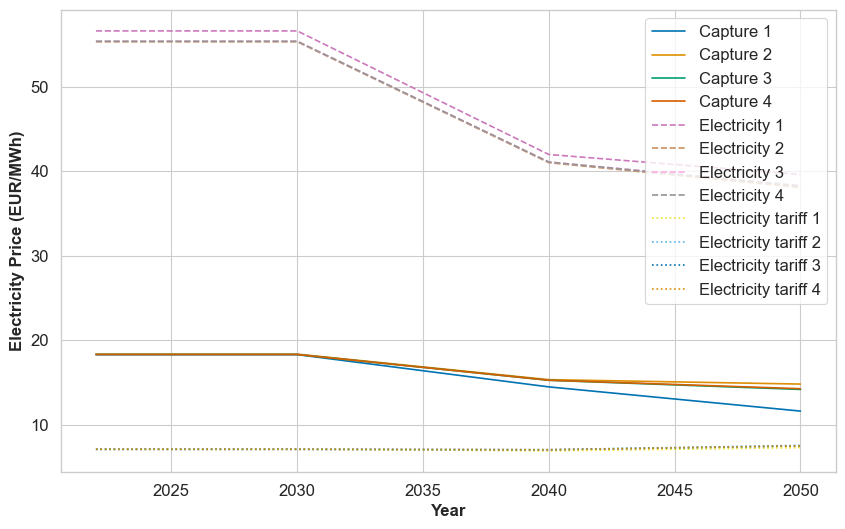

In [ ]:
figure = plt.figure(figsize=(10,6))
plt.plot(capture_price_1, label='Capture 1')
plt.plot(capture_price_2, label='Capture 2')
plt.plot(capture_price_3, label='Capture 3')
plt.plot(capture_price_4, label='Capture 4')
plt.plot(electricity_price_1, label='Electricity 1', linestyle='--')
plt.plot(electricity_price_2, label='Electricity 2', linestyle='--')
plt.plot(electricity_price_3, label='Electricity 3', linestyle='--')
plt.plot(electricity_price_4, label='Electricity 4', linestyle='--')
plt.plot(el_tariff_1, label='Electricity tariff 1', linestyle=':')
plt.plot(el_tariff_2, label='Electricity tariff 2', linestyle=':')
plt.plot(el_tariff_3, label='Electricity tariff 3', linestyle=':')
plt.plot(el_tariff_4, label='Electricity tariff 4', linestyle=':')
# plt.plot(hydrogen_tariff_1, label='Hydrogen tariff 1', linestyle='-.')
# plt.plot(hydrogen_tariff_2, label='Hydrogen tariff 2', linestyle='-.')
# plt.plot(hydrogen_tariff_3, label='Hydrogen tariff 3', linestyle='-.')
# plt.plot(hydrogen_tariff_4, label='Hydrogen tariff 4', linestyle='-.')
plt.xlabel('Year')
plt.ylabel('Electricity Price (EUR/MWh)')
plt.legend()


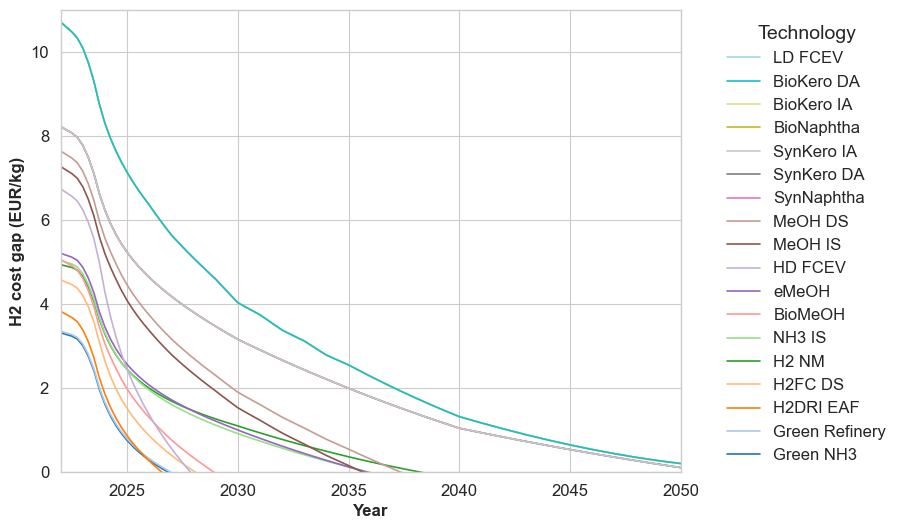

time               2030.0     2040.0     2050.0
Green NH3       -0.695998  -2.084438  -2.687287
Green Refinery  -0.664562  -2.064616  -2.687287
H2DRI EAF       -1.181348  -3.775174  -4.715720
H2FC DS         -0.578460  -2.314433  -3.054247
H2 NM            1.095432  -0.171998  -0.717889
NH3 IS           0.912672  -0.462798  -1.039218
BioMeOH         -0.395980  -3.051453  -4.298144
eMeOH            0.997585  -0.541921  -1.226386
HD FCEV         -1.161109  -3.906953  -5.368510
MeOH IS          1.527952  -0.953174  -2.020066
MeOH DS          1.898014  -0.541993  -1.557488
SynNaphtha       3.157582   1.040854   0.102953
SynKero DA       3.157582   1.040854   0.102953
SynKero IA       3.157582   1.040854   0.102953
BioNaphtha       4.029374   1.316489   0.199546
BioKero IA       4.029374   1.316489   0.199546
BioKero DA       4.029374   1.316489   0.199546
LD FCEV         72.126603  56.727154  48.815365


In [14]:
df_gaps = baseline_results[[tech + " H2 WTP gap" for tech in rl.h2_tech_to_sector_dict.keys()]]
df_gaps.columns = rl.h2_tech_to_sector_dict.keys()
df_gaps = df_gaps.sort_values(by=df_gaps.index[0], axis=1)

fig, ax = plt.subplots()
df_gaps.plot(figsize=(8,6), legend=True,colormap='tab20', ax=ax)
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1], title='Technology', bbox_to_anchor=(1.05, 1), loc='upper left',frameon=False)
plt.xlim(2022,2050)
plt.ylim(0,11)
plt.xlabel('Year')
plt.ylabel('H2 cost gap (EUR/kg)')
plt.show()
print(df_gaps.loc[[2030,2040,2050],].T)

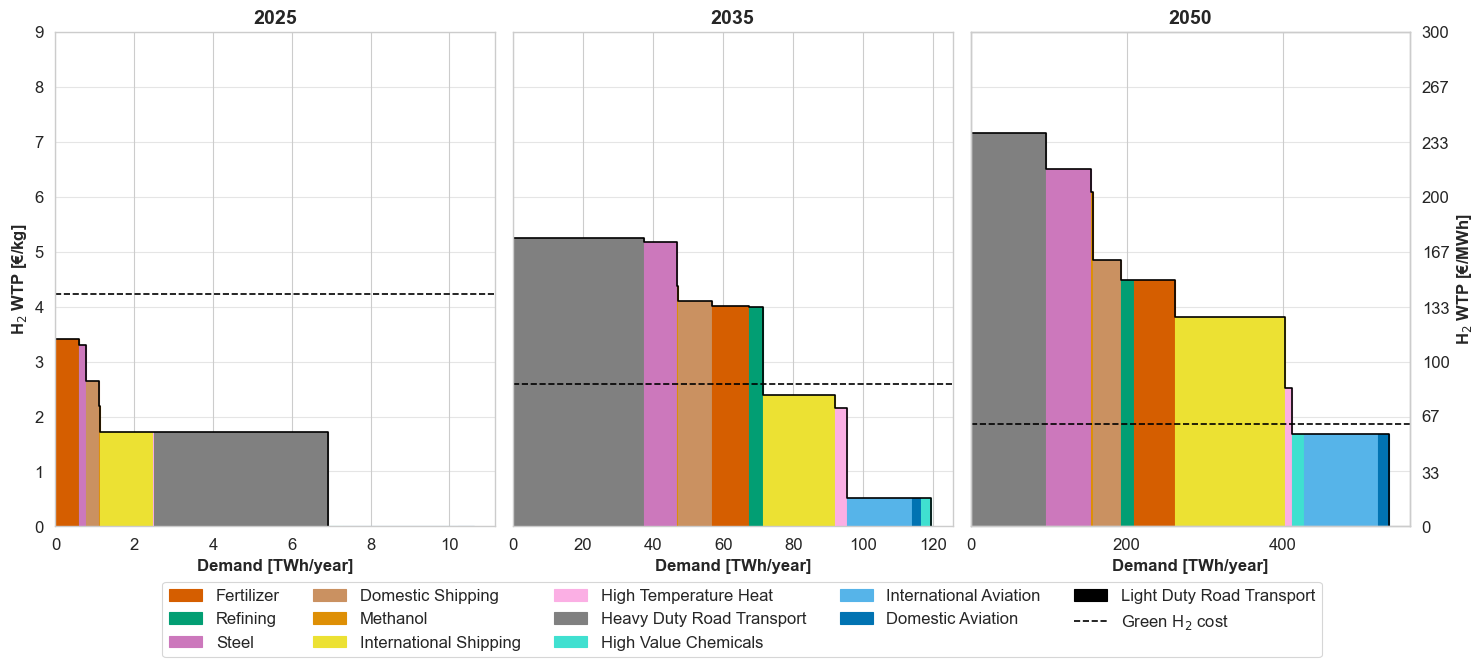

In [241]:
basemodel_results = loop4_results

years_of_interest = np.asarray([2025, 2035, 2050])
modified_price_break_list = list(rl.hydrogen_demands.values()).copy()
modified_price_break_list.pop(0)

d_h2 = basemodel_results[rl.price_break_list].loc[years_of_interest]
h2_quantity_offers = basemodel_results[modified_price_break_list].loc[years_of_interest] * 120/3600/1000 # Load the hydrogen demands (in tons) and convert to TWh

h2_price_offers = pd.DataFrame(index=years_of_interest, columns=h2_quantity_offers.columns)

for main_sector in rl.sector_dict.keys():
    for i, (sub_sector, sub_dict) in enumerate(rl.sector_dict[main_sector].items()):
        for year in years_of_interest:
            if sub_sector + " 2" in rl.price_breaks.keys(): # Check if the sub_sector has a price break for 2 technologies
                # If so, use the maximum of the two price breaks
                price_break_value = max(d_h2[sub_dict["WTP"]].loc[year], d_h2[sub_dict["WTP 2"]].loc[year])
            elif sub_sector in rl.price_breaks.keys():
                price_break_value = d_h2[sub_dict["WTP"]].loc[year]
            else:
                continue
            h2_price_offers.loc[year == years_of_interest, sub_dict["h2 demand"]] = price_break_value # {"Quantity" : d_q[sub_dict["h2 demand"]].loc[year], "WTP" : price_break_value}

clean_column_names = list(name.split(" hydrogen")[0] for name in h2_quantity_offers.columns)
h2_price_offers.columns = clean_column_names
h2_quantity_offers.columns = clean_column_names

sd_plot.plot_demand_curve(years_of_interest=years_of_interest,
                          price_offers=h2_price_offers,
                          quantity_offers=h2_quantity_offers,
                          model_results=basemodel_results,
                          type_="H2",
                          )

# The effect of hydrogen subsidy

## General subsidy

In [14]:
subsidy_model = baseline_model.copy()
subsidy_model.set_components({"Green H2 subsidy size": 1.5,"H2 subsidy length": 15})
time_step = 0.25

final_year = 2050
subsidy_results = subsidy_model.run(final_time=final_year,time_step=time_step)

c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 76.957332 to 77
  warnings.warn(
c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 76.957332 to 77
  warnings.warn(


### standard plots

In [15]:
sd_plot.plot_sector_costs(model_results=subsidy_results,
                          model=subsidy_model,
                          filename="Sector costs general subsidy")

sd_plot.plot_sector_production(model_results=subsidy_results,
                               filename="Sector production general subsidy")

subsidy_yearly, subsidy_emissions = sd_plot.plot_system_emissions(model_results=subsidy_results,
                                                    filename="Sector emissions general subsidy",
                                                    write_df=True,
                                                    cumulative_emissions=False)

sd_plot.plot_hydrogen_projection(subsidy_results,
                                 filename="Hydrogen projection general subsidy",
                                 step_horizontal_lines=200,)

Figure saved at results/Sector costs general subsidy_industry.png
Figure saved at results/Sector costs general subsidy_transport.png
Figure saved at results/Sector production general subsidy_industry.png
Figure saved at results/Sector production general subsidy_transport.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Hydrogen projection general subsidy.png


### multe-run journal

In [199]:
dict_subsidy_solutions = {}
dict_budgets = {}
subsidy_sizes = [1.0, 1.5, 2.0, 2.5, 3.0] # €/kg subsidy size NOTE this is the journal settings
subsidy_length = 15 # years of subsidy length
final_year = 2050

for size in subsidy_sizes:
    model_loop = baseline_model.copy()
    model_loop.set_components({"Green H2 subsidy size": size,"H2 subsidy length": subsidy_length})
    results_loop = model_loop.run(final_time=final_year,time_step=time_step)
    dict_subsidy_solutions[size] = results_loop
    allocations = np.asarray([results_loop["Support " + tech].values for tech in rl.h2_tech_to_sector_dict.keys()])
    results_loop['allocation sum'] = allocations.sum(axis=0)
    df_budget = results_loop["allocation sum"].copy() # Load and convert to B€/year
    dict_budgets[size] = df_budget

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a va

## Plots for Conference Proceeding version of the paper

In [ ]:
# Here we make a loop to run the model with different combinations of subsidy size and subsidy length
dict_subsidy_solutions = {}
subsidy_sizes = [1.0, 1.5, 2.0, 2.5, 3.0] # €/kg subsidy size NOTE this is the proceeding settings
subsidy_lengths = [10, 15, 20] # years of subsidy length NOTE this is the proceeding settings
# subsidy_sizes = [1.0, 2.0, 3.0, 4.0] # €/kg subsidy size NOTE this is the journal settings
# subsidy_length = 15 # years of subsidy length
final_year = 2050

for size in subsidy_sizes:
    # model_loop = baseline_model.copy()
    # model_loop.set_components({"Green H2 subsidy size": size,"H2 subsidy length": subsidy_length})
    # results_loop = model_loop.run(final_time=final_year,time_step=time_step)
    # dict_subsidy_solutions[size] = results_loop
    for length in subsidy_lengths:
        model_loop = baseline_model.copy()
        model_loop.set_components({"Green H2 subsidy size": size,"H2 subsidy length": length})
        results_loop = model_loop.run(final_time=final_year,time_step=time_step)
        dict_subsidy_solutions[(size, length)] = results_loop

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")


### conference pre-calculations

In [9]:
dict_policy_costs = {}
dict_cumulative_emissions = {}
dict_yearly_emissions = {}
dict_hydrogen_demands_2050 = {}
dict_abatement_costs = {}
dict_hydrogen_demand_efficiency = {}
baseline_cumulative_emissions = baseline_emissions.loc[2050].sum()
baseline_cumulative_hydrogen_demand = baseline_results[['INDUSTRY TWH', 'TRANSPORTATION TWH',]].cumsum().iloc[-1].sum(axis=0) * time_step # TWh cumulative hydrogen demand until 2050
baseline_hydrogen_demand_2050 = baseline_results[['INDUSTRY TWH', 'TRANSPORTATION TWH',]].iloc[-1].sum(axis=0) # TWh hydrogen demand in 2050
for key, results in dict_subsidy_solutions.items():
    allocations = np.asarray([results["Support " + tech].values for tech in rl.h2_tech_to_sector_dict.keys()])
    results["allocation sum"] = np.sum(allocations, axis=0)
    time = results["TIME STEP"].iloc[0]
    policy_cost = np.sum(results['allocation sum']*time)
    results_yearly, results_emissions = sd_plot.plot_system_emissions(model_results=results,
                                                    filename="Sector emissions general subsidy",
                                                    write_df=True,
                                                    cumulative_emissions=False)
    cumulative_emissions = results_emissions.loc[2050].sum()
    cumulative_emissions_reduction = baseline_cumulative_emissions - cumulative_emissions
    hydrogen_demand_2050 = results[['INDUSTRY TWH', 'TRANSPORTATION TWH',]].iloc[-1].sum(axis=0)
    hydrogen_cumulative_demand_2050 = results[['INDUSTRY TWH', 'TRANSPORTATION TWH',]].cumsum().iloc[-1].sum(axis=0) * time
    demand_2050 = hydrogen_demand_2050 / 33.33
    added_cumulative_demand_2050 = hydrogen_cumulative_demand_2050 - baseline_cumulative_hydrogen_demand
    abatement_cost = (policy_cost / cumulative_emissions_reduction) # €/ton CO2 - average price of each abated ton CO2
    demand_efficiency = policy_cost / added_cumulative_demand_2050 * 33.33 # €/kg
    dict_policy_costs[key] = policy_cost
    dict_cumulative_emissions[key] = cumulative_emissions_reduction
    dict_yearly_emissions[key] = results_yearly.loc[2050].sum()
    dict_hydrogen_demands_2050[key] = demand_2050
    dict_abatement_costs[key] = abatement_cost
    dict_hydrogen_demand_efficiency[key] = demand_efficiency

Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png
Figure saved at results/Sector emissions general subsidy.png


### conference figure 1

subsidy_length (years)           10           15           20
subsidy_size (€/kg)                                          
1.0                       96.692606   264.388510   542.268543
1.5                      285.139440   706.207833  1402.394600
2.0                      606.611124  1437.662201  2442.941366
2.5                     1007.205759  2122.127382  3382.918580
3.0                     1345.418078  2687.562960  4201.088123


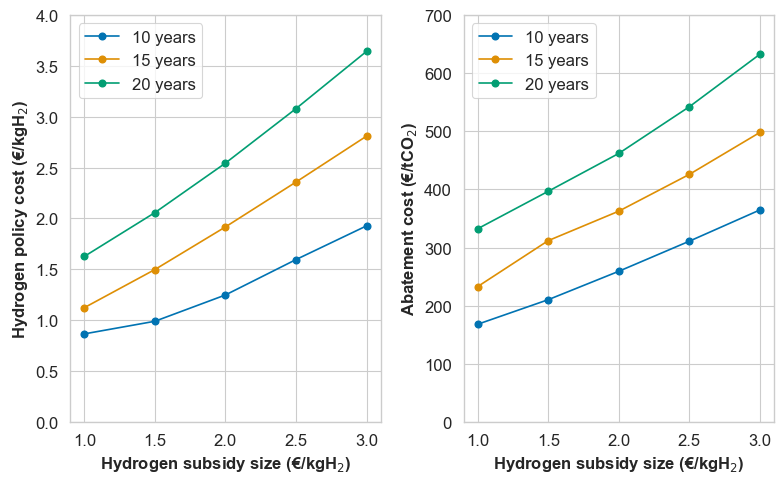

In [18]:
import seaborn as sns

heatmap_df1 = pd.Series(dict_abatement_costs).rename("abatement_cost").reset_index()
heatmap_df2 = pd.Series(dict_hydrogen_demands_2050).rename("hydrogen_demand").reset_index()
heatmap_df3 = pd.Series(dict_policy_costs).rename("policy_cost").reset_index()
heatmap_df4 = pd.Series(dict_cumulative_emissions).rename("cumulative_emissions").reset_index()
heatmap_df5 = pd.Series(dict_yearly_emissions).rename("yearly_emissions").reset_index()
heatmap_df6 = pd.Series(dict_hydrogen_demand_efficiency).rename("hydrogen_demand_efficiency").reset_index()


heatmap_df1 = heatmap_df1.rename(columns={"level_0": "subsidy_size (€/kg)", "level_1": "subsidy_length (years)"})
heatmap_df2 = heatmap_df2.rename(columns={"level_0": "subsidy_size (€/kg)", "level_1": "subsidy_length (years)"})
heatmap_df3 = heatmap_df3.rename(columns={"level_0": "subsidy_size (€/kg)", "level_1": "subsidy_length (years)"})
heatmap_df4 = heatmap_df4.rename(columns={"level_0": "subsidy_size (€/kg)", "level_1": "subsidy_length (years)"})
heatmap_df5 = heatmap_df5.rename(columns={"level_0": "subsidy_size (€/kg)", "level_1": "subsidy_length (years)"})
heatmap_df6 = heatmap_df6.rename(columns={"level_0": "subsidy_size (€/kg)", "level_1": "subsidy_length (years)"})

heatmap_df1 = heatmap_df1.pivot(index=heatmap_df1.columns[0], columns=heatmap_df1.columns[1], values="abatement_cost")
heatmap_df2 = heatmap_df2.pivot(index=heatmap_df2.columns[0], columns=heatmap_df2.columns[1], values="hydrogen_demand")
heatmap_df3 = heatmap_df3.pivot(index=heatmap_df3.columns[0], columns=heatmap_df3.columns[1], values="policy_cost")
heatmap_df4 = heatmap_df4.pivot(index=heatmap_df4.columns[0], columns=heatmap_df4.columns[1], values="cumulative_emissions")
heatmap_df5 = heatmap_df5.pivot(index=heatmap_df5.columns[0], columns=heatmap_df5.columns[1], values="yearly_emissions")
heatmap_df6 = heatmap_df6.pivot(index=heatmap_df6.columns[0], columns=heatmap_df6.columns[1], values="hydrogen_demand_efficiency")

print(heatmap_df3)

fig, axs = plt.subplots(1,2,figsize=(8, 5))

axs[0].plot(heatmap_df6.loc[:, 10].index, heatmap_df6.loc[:, 10].values, marker='o', label="10 years")
axs[0].plot(heatmap_df6.loc[:, 15].index, heatmap_df6.loc[:, 15].values, marker='o', label="15 years")
axs[0].plot(heatmap_df6.loc[:, 20].index, heatmap_df6.loc[:, 20].values, marker='o', label="20 years")

axs[0].set_title("")
axs[0].set_xlabel("Hydrogen subsidy size (€/kgH$_{2}$)")
axs[0].set_ylabel("Hydrogen policy cost (€/kgH$_{2}$)")
axs[0].legend()

axs[0].set_ylim(0, 4)

axs[1].plot(heatmap_df1.loc[:, 10].index, heatmap_df1.loc[:, 10].values, marker='o', label="10 years")
axs[1].plot(heatmap_df1.loc[:, 15].index, heatmap_df1.loc[:, 15].values, marker='o', label="15 years")
axs[1].plot(heatmap_df1.loc[:, 20].index, heatmap_df1.loc[:, 20].values, marker='o', label="20 years")

axs[1].set_title("")
axs[1].set_xlabel("Hydrogen subsidy size (€/kgH$_{2}$)")
axs[1].set_ylabel("Abatement cost (€/tCO$_{2}$)")
axs[1].legend()

axs[1].set_ylim(0, 700)

plt.tight_layout()
plt.show()

### conference figure 2

In [23]:
sd_plot.plot_sector_production(model_results=dict_subsidy_solutions[(3, 15)],
                               filename="Sector production (3,15)")

Figure saved at results/Sector production (3,15)_industry.png
Figure saved at results/Sector production (3,15)_transport.png


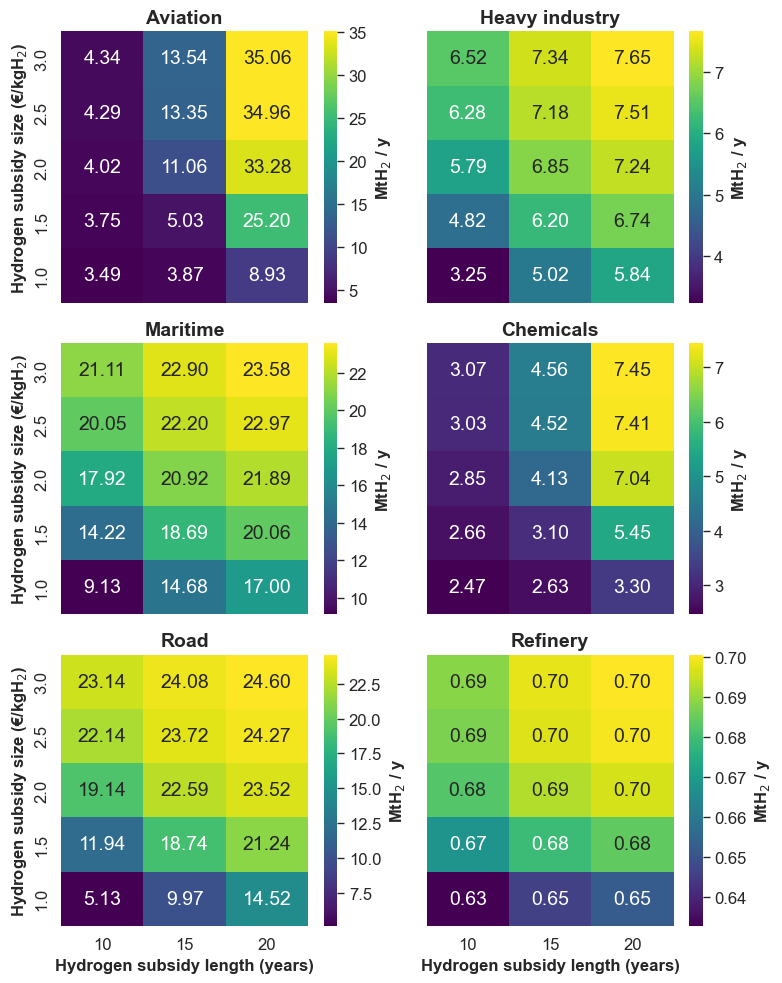

In [16]:
import seaborn as sns

industry_h2_demands = ["naphtha hydrogen demand", "refinery hydrogen demand", "fertilizer hydrogen demand", 
                           "steel hydrogen demand", "high temperature hydrogen demand", "MeOH hydrogen demand"]
transport_h2_demand = ["light duty hydrogen demand", "heavy duty hydrogen demand", "domestic shipping hydrogen demand",
                       "international shipping hydrogen demand", "domestic aviation hydrogen demand", "international aviation hydrogen demand"]
all_h2_demands = industry_h2_demands + transport_h2_demand

grouping_of_sectors = {"naphtha hydrogen demand": "Chemical industry",
                       "refinery hydrogen demand": "Refinery industry",
                       "fertilizer hydrogen demand": "Chemical industry",
                          "steel hydrogen demand": "Heavy industry",
                            "high temperature hydrogen demand": "Heavy industry",
                            "MeOH hydrogen demand": "Chemical industry",
                            "light duty hydrogen demand": "Road transport",
                            "heavy duty hydrogen demand": "Road transport",
                            "domestic shipping hydrogen demand": "Maritime transport",
                            "international shipping hydrogen demand": "Maritime transport",
                            "domestic aviation hydrogen demand": "Aviation",
                            "international aviation hydrogen demand": "Aviation",}

dict_sector_h2_demands = {}

heatmap_aviation = pd.DataFrame(index=[1.0, 1.5, 2.0, 2.5, 3.0], columns=[10, 15, 20])
heatmap_maritime = pd.DataFrame(index=[1.0, 1.5, 2.0, 2.5, 3.0], columns=[10, 15, 20])
heatmap_road = pd.DataFrame(index=[1.0, 1.5, 2.0, 2.5, 3.0], columns=[10, 15, 20])
heatmap_industry = pd.DataFrame(index=[1.0, 1.5, 2.0, 2.5, 3.0], columns=[10, 15, 20])
heatmap_chemical = pd.DataFrame(index=[1.0, 1.5, 2.0, 2.5, 3.0], columns=[10, 15, 20])
heatmap_refinery = pd.DataFrame(index=[1.0, 1.5, 2.0, 2.5, 3.0], columns=[10, 15, 20])

for key, results in dict_subsidy_solutions.items():
    size, duration = key
    hydrogen_demand = results[all_h2_demands].iloc[-1] / 1e6  # From t -> Mt
    # if size == 2.0 and duration == 15:
    #     temp_heatmap_aviation = results[["domestic aviation hydrogen demand", "international aviation hydrogen demand"]].sum(axis=1) / 1e6
    hydrogen_demand = hydrogen_demand.groupby(grouping_of_sectors).sum()
    if hydrogen_demand.get("Aviation") is not None:
        heatmap_aviation.loc[size, duration] = hydrogen_demand["Aviation"]
    if hydrogen_demand.get("Maritime transport") is not None:
        heatmap_maritime.loc[size, duration] = hydrogen_demand["Maritime transport"]
    if hydrogen_demand.get("Road transport") is not None:
        heatmap_road.loc[size, duration] = hydrogen_demand["Road transport"]
    if hydrogen_demand.get("Heavy industry") is not None:
        heatmap_industry.loc[size, duration] = hydrogen_demand["Heavy industry"]
    if hydrogen_demand.get("Chemical industry") is not None:
        heatmap_chemical.loc[size, duration] = hydrogen_demand["Chemical industry"]
    if hydrogen_demand.get("Refinery industry") is not None:
        heatmap_refinery.loc[size, duration] = hydrogen_demand["Refinery industry"]

# temp_heatmap_aviation.plot(figsize=(8,5), marker='o')

heatmap_aviation.sort_values(by=heatmap_aviation.columns[-1], ascending=False, inplace=True)
heatmap_maritime.sort_values(by=heatmap_maritime.columns[-1], ascending=False, inplace=True)
heatmap_road.sort_values(by=heatmap_road.columns[-1], ascending=False, inplace=True)
heatmap_industry.sort_values(by=heatmap_industry.columns[-1], ascending=False, inplace=True)
heatmap_chemical.sort_values(by=heatmap_chemical.columns[-1], ascending=False, inplace=True)
heatmap_refinery.sort_values(by=heatmap_refinery.columns[-1], ascending=False, inplace=True)

fig, axs = plt.subplots(3, 2, figsize=(8, 10))
heatmaps = [heatmap_aviation, heatmap_industry, heatmap_maritime, heatmap_chemical, heatmap_road, heatmap_refinery]
titles = ["Aviation", "Heavy industry", "Maritime", "Chemicals", "Road", "Refinery"]

for idx, (ax, heatmap, title) in enumerate(zip(axs.flat, heatmaps, titles)):
    sns.heatmap(heatmap.astype(float), annot=True, fmt=".2f", cmap="viridis", ax=ax, annot_kws={"size": 14}, cbar_kws={"label": "MtH$_2$ / y"})
    ax.set_title(title)

axs[0,0].set_xticklabels('')
axs[0,1].set_xticklabels('')
axs[1,0].set_xticklabels('')
axs[1,1].set_xticklabels('')
axs[0,1].set_yticklabels('')
axs[1,1].set_yticklabels('')
axs[2,1].set_yticklabels('')

axs[0,0].set_ylabel('Hydrogen subsidy size (€/kgH$_{2}$)')
axs[1,0].set_ylabel('Hydrogen subsidy size (€/kgH$_{2}$)')
axs[2,0].set_ylabel('Hydrogen subsidy size (€/kgH$_{2}$)')
axs[2,0].set_xlabel('Hydrogen subsidy length (years)')
axs[2,1].set_xlabel('Hydrogen subsidy length (years)')

plt.tight_layout()
plt.show()

## Looping Premium

### loop 1

In [16]:
# Here we loop on the general subsidy model to check convergence
sub1_results, sub1_model = make_loop.make_loop(model = subsidy_model,
                                    gdx_file = 'MainResults_subsidy.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '_subsidy\\loop1',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


Loading gdxfiles\MainResults_subsidy.gdx


c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()
c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


Loading gdxfiles\MainResults_subsidy.gdx
Loading gdxfiles\MainResults_subsidy.gdx


c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (54.1.0).
  ws = gams.GamsWorkspace()


Loading gdxfiles\MainResults_subsidy.gdx


c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 87.076950 to 87
  warnings.warn(
c:\GitHub\Balmorel_HyADOPTS_couple\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 87.076950 to 87
  warnings.warn(


Checkpoint 1: Model has run
                                                GDTYPE     GDFUEL  GDCV  \
GNR_ELYS_ELEC_AEC                     HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2020               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2030               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2040               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_Y-2050               HYDROGEN_GETOH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2020           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2030           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2040           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_ELYS_ELEC_AEC_DH_Y-2050           HYDROGEN_GETOHH2   ELECTRIC   0.0   
GNR_FC_H2_SOFCC                        HYDROGEN_GH2TOE   HYDROGEN   0.0   
GNR_FC_H2_SOFCC_Y-2020                 HYDROGEN_GH2TOE   HYDROGEN   0.0   
GNR_FC_H2_SOFCC_Y-2030                 HYDROGEN_GH2TOE   HYDROGEN   0.0 

### loop 2

In [7]:
# loop 2
sub2_results, sub2_model = make_loop.make_loop(model = subsidy_model,
                                    gdx_file = 'MainResults_subsidy2.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '_subsidy\\loop2',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy2.gdx


c:\GitHub\h2_system_dynamics_paper\python_scripts\balmorel_loading.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_consumption_electrolyzer.drop(columns=['Area','Generation','Fuel','Unit','Technology'], inplace=True)
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy2.gdx
Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy2.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy2.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 86.607875 to 87
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 86.607875 to 87
  warnings.warn(


Checkpoint 1: Model has run


### loop 3

In [13]:
# loop 3
sub3_results, sub3_model = make_loop.make_loop(model = subsidy_model,
                                    gdx_file = 'MainResults_subsidy3.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '_subsidy\\loop3',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )
subsidy_results = sub3_results

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy3.gdx


c:\GitHub\h2_system_dynamics_paper\python_scripts\balmorel_loading.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_consumption_electrolyzer.drop(columns=['Area','Generation','Fuel','Unit','Technology'], inplace=True)
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy3.gdx
Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy3.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy3.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 86.625975 to 87
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 86.625975 to 87
  warnings.warn(


Checkpoint 1: Model has run


## HBA subsidy

### old stuff

In [ ]:
dict_hba_solutions = {}

for budget in dict_budgets:
    budget_plan = dict_budgets[budget]

    hba_model = baseline_model.copy()
    hba_model.set_components({"HBA": 1})
    hba_model.set_components({"HBA budget plan": budget_plan,"bid increase" : 1, "HBA duration": 25, "HBA max subsidy": 10.0})

    def real_hba_auction():
        hba = hba_model.components.hba()
        budget = hba_model.components.hba_budget()
        max_subsidy = hba_model.components.hba_max_subsidy()
        if bool(hba):
            bids = [] # For each technology we build a list entry: ("tech_name", volume, ask_price)
            bid_increaser = hba_model.components.bid_increase()        
            for tech, sub_sector in rl.h2_tech_to_sector_dict.items():
                ask_price   = hba_model.components.__getattribute__(tech.replace(" ", "_").lower() + "_h2_wtp_gap")() # €/kg H2 subsidy ask
                if bid_increaser > 1:
                    ask_price = max(min(ask_price + bid_increaser, max_subsidy), ask_price) # Increase bid price according to bid increaser but cap at max subsidy
                vol         = hba_model.components.__getattribute__(tech.replace(" ", "_").lower() + "_hba_volume")() # t H2/yr investment bid
                ask_period  = rl.sector_to_lifetime.get(sub_sector, 10) # years of support asked for
                ask_funding = (ask_price > 0) * ask_price * vol * ask_period * 1000 * 1e-9 # Units are €/kg * t/yr * yr * kg/t * B€/€ = B€
                bids.append([tech, ask_funding, ask_price])
            sorted_bids = sorted(bids, key=lambda bid: bid[2])
            sorted_funding = np.asarray(sorted_bids)[:,1].astype(float)
            sorted_asks = np.asarray(sorted_bids)[:,2].astype(float)
            cum_funding = np.cumsum(sorted_funding)
            clearing_ix = sum(cum_funding < budget)-1
            highest_accepted_ask = sorted_asks[max(clearing_ix, 0)] if clearing_ix>=0 else 0 # The last ask within budget is the highest accepted.
            return min(highest_accepted_ask,max_subsidy) # Cap of 3.5 https://www.spglobal.com/commodity-insights/en/news-research/latest-news/energy-transition/043024-eus-hydrogen-bank-auction-clears-below-50-euro-centkg-funding-15-gw
        else:
            return 0
    hba_model.components.hba_auction = real_hba_auction # Define the auction logic

    def bid_increase_function():
        time_step = hba_model.components.time_step()
        alpha = max(min(1, 1 - 4 * time_step), 0) # Smoothing factor for bid increase adjustment
        allocated = hba_model.components.allocated_money_previous()
        budget = hba_model.components.hba_budget_previous()
        previous_bid_increase = hba_model.components.bid_increase_previous()
        new_bid_increase = 1
        if allocated > 0 and budget > 0:
            new_bid_increase = max(1, np.sqrt(budget / allocated))
        return alpha * previous_bid_increase + (1 - alpha) * new_bid_increase
    hba_model.components.bid_increase = bid_increase_function
    hba_model.components.hba_auction = real_hba_auction # Define the auction logic
    hba_results = hba_model.run(final_time=final_year)
    dict_hba_solutions[budget] = hba_results

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1133: UserWarning: Replacing a constant value with a callable. The value may not be constant anymore.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1133: UserWarning: Replacing a constant value with a callable. The value may not be constant anymore.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value.

### newer stuff

In [14]:
allocations = np.asarray([subsidy_results["Support " + tech].values for tech in rl.h2_tech_to_sector_dict.keys()])
subsidy_results['allocation sum'] = allocations.sum(axis=0)
df_budget = subsidy_results["allocation sum"].copy() # Load and convert to B€/year
print(np.sum(subsidy_results['allocation sum']*time_step))
print(subsidy_results['total hba cost'].iloc[-1])

hba_model = baseline_model.copy()
hba_model.set_components({"HBA": 1})
hba_model.set_components({"HBA budget plan": df_budget, "bid increase" : 1, "HBA duration": 25, "HBA max subsidy": 5.0})

capture_price, electricity_price = bal_loading.load_balmorel_electricity_prices(gdx_file = 'MainResults_subsidy3.gdx',
                                                                          path='gdxfiles',
                                                                           )
electricity_tariff = bal_loading.load_balmorel_electricity_tariff(gdx_file = 'MainResults_subsidy3.gdx',
                                                                          path='gdxfiles',
                                                                            )
hydrogen_tariff = bal_loading.load_balmorel_hydrogen_tariff(gdx_file = 'MainResults_subsidy3.gdx',
                                                                        path='gdxfiles',
                                                                        )
electrolyser_fullloadhours = bal_loading.load_balmorel_fullloadhours(gdx_file = 'MainResults_subsidy3.gdx',
                                                                        path='gdxfiles',
                                                                        )
capture_price = capture_price + electricity_tariff # Adding electricity tariff to the electrolyzer electricity price
electricity_price = electricity_price + electricity_tariff # Adding electricity tariff to the average electricity price in the system

hba_model.set_components({"RENEWABLE ELECTRICITY PRICE": capture_price})
hba_model.set_components({"GRID ELECTRICITY PRICE": electricity_price})
hba_model.set_components({"Green H2 tariff": hydrogen_tariff})
hba_model.set_components({"electrolyser operating hours": electrolyser_fullloadhours})


def real_hba_auction():
    hba = hba_model.components.hba()
    budget = hba_model.components.hba_budget()
    max_subsidy = hba_model.components.hba_max_subsidy()
    if bool(hba):
        bids = [] # For each technology we build a list entry: ("tech_name", volume, ask_price)
        bid_increaser = hba_model.components.bid_increase()        
        for tech, sub_sector in rl.h2_tech_to_sector_dict.items():
            ask_price   = hba_model.components.__getattribute__(tech.replace(" ", "_").lower() + "_h2_wtp_gap")() # €/kg H2 subsidy ask
            if bid_increaser > 1:
                ask_price = max(min(ask_price + bid_increaser, max_subsidy), ask_price) # Increase bid price according to bid increaser but cap at max subsidy
            vol         = hba_model.components.__getattribute__(tech.replace(" ", "_").lower() + "_hba_volume")() # t H2/yr investment bid
            ask_period  = rl.sector_to_lifetime.get(sub_sector, 10) # years of support asked for
            ask_funding = (ask_price > 0) * ask_price * vol * ask_period * 1000 * 1e-9 # Units are €/kg * t/yr * yr * kg/t * B€/€ = B€
            bids.append([tech, ask_funding, ask_price])
        sorted_bids = sorted(bids, key=lambda bid: bid[2])
        sorted_funding = np.asarray(sorted_bids)[:,1].astype(float)
        sorted_asks = np.asarray(sorted_bids)[:,2].astype(float)
        cum_funding = np.cumsum(sorted_funding)
        clearing_ix = sum(cum_funding < budget)-1
        highest_accepted_ask = sorted_asks[max(clearing_ix, 0)] if clearing_ix>=0 else 0 # The last ask within budget is the highest accepted.
        return min(highest_accepted_ask,max_subsidy) # Cap of 3.5 https://www.spglobal.com/commodity-insights/en/news-research/latest-news/energy-transition/043024-eus-hydrogen-bank-auction-clears-below-50-euro-centkg-funding-15-gw
    else:
        return 0
hba_model.components.hba_auction = real_hba_auction # Define the auction logic

def bid_increase_function():
    time_step = hba_model.components.time_step()
    alpha = max(min(1, 1 - 4 * time_step), 0) # Smoothing factor for bid increase adjustment
    allocated = hba_model.components.allocated_money_previous()
    budget = hba_model.components.hba_budget_previous()
    previous_bid_increase = hba_model.components.bid_increase_previous()
    new_bid_increase = 1
    if allocated > 0 and budget > 0:
        new_bid_increase = max(1, np.sqrt(budget / allocated))
    return alpha * previous_bid_increase + (1 - alpha) * new_bid_increase
hba_model.components.bid_increase = bid_increase_function

hba_results = hba_model.run(final_time=final_year,time_step=time_step)

1018.9987114002903
993.7802000298387


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy3.gdx


c:\GitHub\h2_system_dynamics_paper\python_scripts\balmorel_loading.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_consumption_electrolyzer.drop(columns=['Area','Generation','Fuel','Unit','Technology'], inplace=True)
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy3.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy3.gdx
Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_subsidy3.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1133: UserWarning: Replacing a constant value with a callable. The value may not be constant anymore.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 86.625975 to 87
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 86.625975 to 87
  warnings.warn(


### standard plots

In [74]:
sd_plot.plot_sector_costs(model_results=hba_results,
                          model=hba_model,
                          filename="Sector cost HBA subsidy")

sd_plot.plot_sector_production(model_results=hba_results,
                               filename="Sector production HBA subsidy")

hba_yearly, hba_emissions = sd_plot.plot_system_emissions(model_results=hba_results,
                                                filename="Sector emissions HBA subsidy",
                                                write_df=True,
                                                cumulative_emissions=False)

sd_plot.plot_hydrogen_projection(hba_results,
                                 filename="Hydrogen projection HBA subsidy",
                                 step_horizontal_lines=200,)

Figure saved at results/Sector cost HBA subsidy_industry.png
Figure saved at results/Sector cost HBA subsidy_transport.png
Figure saved at results/Sector production HBA subsidy_industry.png
Figure saved at results/Sector production HBA subsidy_transport.png
Figure saved at results/Sector emissions HBA subsidy.png
Figure saved at results/Hydrogen projection HBA subsidy.png


### Budget overview

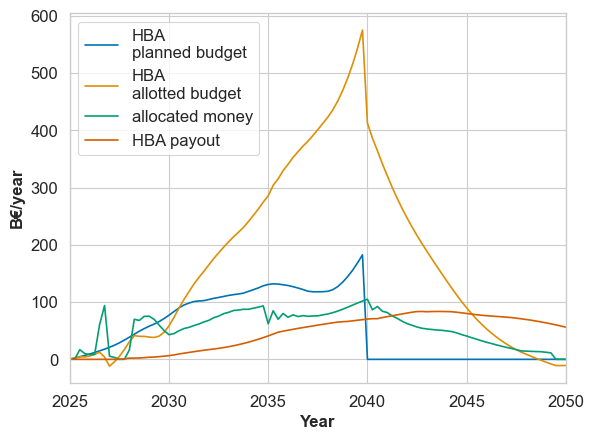

Total budget:  1349.179548542729 B€
Excess payouts: -186.8429797943007 B€


In [75]:
hba_results['HBA budget plan'].plot(label="HBA\nplanned budget")
hba_results['HBA budget'].plot(label="HBA\nallotted budget")
hba_results['allocated money'].plot()
hba_results['hba payout'].plot(label="HBA payout")
plt.ylabel("B€/year")
plt.xlabel("Year")
plt.xlim(2025,2050)
# plt.ylim(0,200)
plt.legend()
plt.show()
print("Total budget: ", np.sum(hba_results['HBA budget plan'] * hba_results["TIME STEP"].iloc[0]), "B€")
print("Excess payouts:", np.sum(hba_results['hba payout'] - hba_results['HBA budget plan']) * hba_results["TIME STEP"].iloc[0], "B€")

## Looping HBA

### loop 1

In [ ]:
# Loop 1 --- somethin is missing here, the budget should be defined by the subsidy run, so use those prices as well
hba1_results, hba1_model = make_loop.make_loop(model = hba_model,
                                    gdx_file = 'MainResults_subsidy3.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '_hba\\loop1',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

## Mandates

In [10]:
mandate_model = baseline_model.copy()
mandate_model.set_components({"Hard Regulation": 1})

final_year = 2050
mandate_results = mandate_model.run(final_time=final_year, time_step=time_step)

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 76.957332 to 77
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 76.957332 to 77
  warnings.warn(


### standard plots

In [16]:
sd_plot.plot_sector_costs(model_results=mandate_results,
                          model=mandate_model,
                          filename="Sector costs mandates")

sd_plot.plot_sector_production(model_results=mandate_results,
                               filename="Sector production mandates")

mandate_yearly, mandate_emissions = sd_plot.plot_system_emissions(model_results=mandate_results,
                                                    filename="Sector emissions mandates",
                                                    write_df=True,
                                                cumulative_emissions=False)

sd_plot.plot_hydrogen_projection(mandate_results,
                                 filename="Hydrogen projection mandates",
                                 step_horizontal_lines=200,)

Figure saved at results/Sector costs mandates_industry.png
Figure saved at results/Sector costs mandates_transport.png
Figure saved at results/Sector production mandates_industry.png
Figure saved at results/Sector production mandates_transport.png
Figure saved at results/Sector emissions mandates.png
Figure saved at results/Hydrogen projection mandates.png


## Looping mandates

### loop 1

In [7]:
# Loop 1
man1_results, man1_model = make_loop.make_loop(model = mandate_model,
                                    gdx_file = 'MainResults_mandate.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '_mandate\\loop1',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate.gdx


c:\GitHub\h2_system_dynamics_paper\python_scripts\balmorel_loading.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_consumption_electrolyzer.drop(columns=['Area','Generation','Fuel','Unit','Technology'], inplace=True)
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate.gdx
Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 91.298462 to 91
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 91.298462 to 91
  warnings.warn(


Checkpoint 1: Model has run


### loop 2

In [9]:
# Loop 2
man2_results, man2_model = make_loop.make_loop(model = mandate_model,
                                    gdx_file = 'MainResults_mandate2.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '_mandate\\loop2',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate2.gdx


c:\GitHub\h2_system_dynamics_paper\python_scripts\balmorel_loading.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_consumption_electrolyzer.drop(columns=['Area','Generation','Fuel','Unit','Technology'], inplace=True)
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate2.gdx
Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate2.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate2.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 91.450729 to 91
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 91.450729 to 91
  warnings.warn(


Checkpoint 1: Model has run


### loop 3

In [11]:
# Loop 3
man3_results, man3_model = make_loop.make_loop(model = mandate_model,
                                    gdx_file = 'MainResults_mandate3.gdx',
                                    in_path= 'gdxfiles',
                                    out_path = '_mandate\\loop3',
                                    distribution_key=distribution_keys,
                                    hydrogen_data=hydrogen_data,
                                    electricity_demand=electricity_demand
                                    )

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate3.gdx


c:\GitHub\h2_system_dynamics_paper\python_scripts\balmorel_loading.py:90: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  fuel_consumption_electrolyzer.drop(columns=['Area','Generation','Fuel','Unit','Technology'], inplace=True)
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate3.gdx
Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate3.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pybalmorel\classes.py:103: UserWarning: The GAMS version (49.2.0) differs from the API version (51.3.0).
  ws = gams.GamsWorkspace()


Loading c:\GitHub\h2_system_dynamics_paper\gdxfiles\MainResults_mandate3.gdx


c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_electrolyzer_investments_delayed
Casting delay order from 91.478240 to 91
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\statefuls.py:378: UserWarning: _delayfixed_green_refinery_delayed
Casting delay order from 91.478240 to 91
  warnings.warn(


Checkpoint 1: Model has run


## Write CSV

In [15]:
baseline_results.to_csv("vensim_results_main\\baseline_results.csv",index=True)
sub3_results.to_csv("vensim_results_main\\subsidy_results.csv",index=True)
hba_results.to_csv("vensim_results_main\\hba_results.csv",index=True)
man3_results.to_csv("vensim_results_main\\mandate_results.csv",index=True)

### Load CSV

In [1]:
import pandas as pd
baseline_results = pd.read_csv("vensim_results_main\\baseline_results.csv", index_col=0)
subsidy_results = pd.read_csv("vensim_results_main\\subsidy_results.csv", index_col=0)
hba_results = pd.read_csv("vensim_results_main\\hba_results.csv", index_col=0)
mandate_results = pd.read_csv("vensim_results_main\\mandate_results.csv", index_col=0)

## Post analysis

### Effective cost

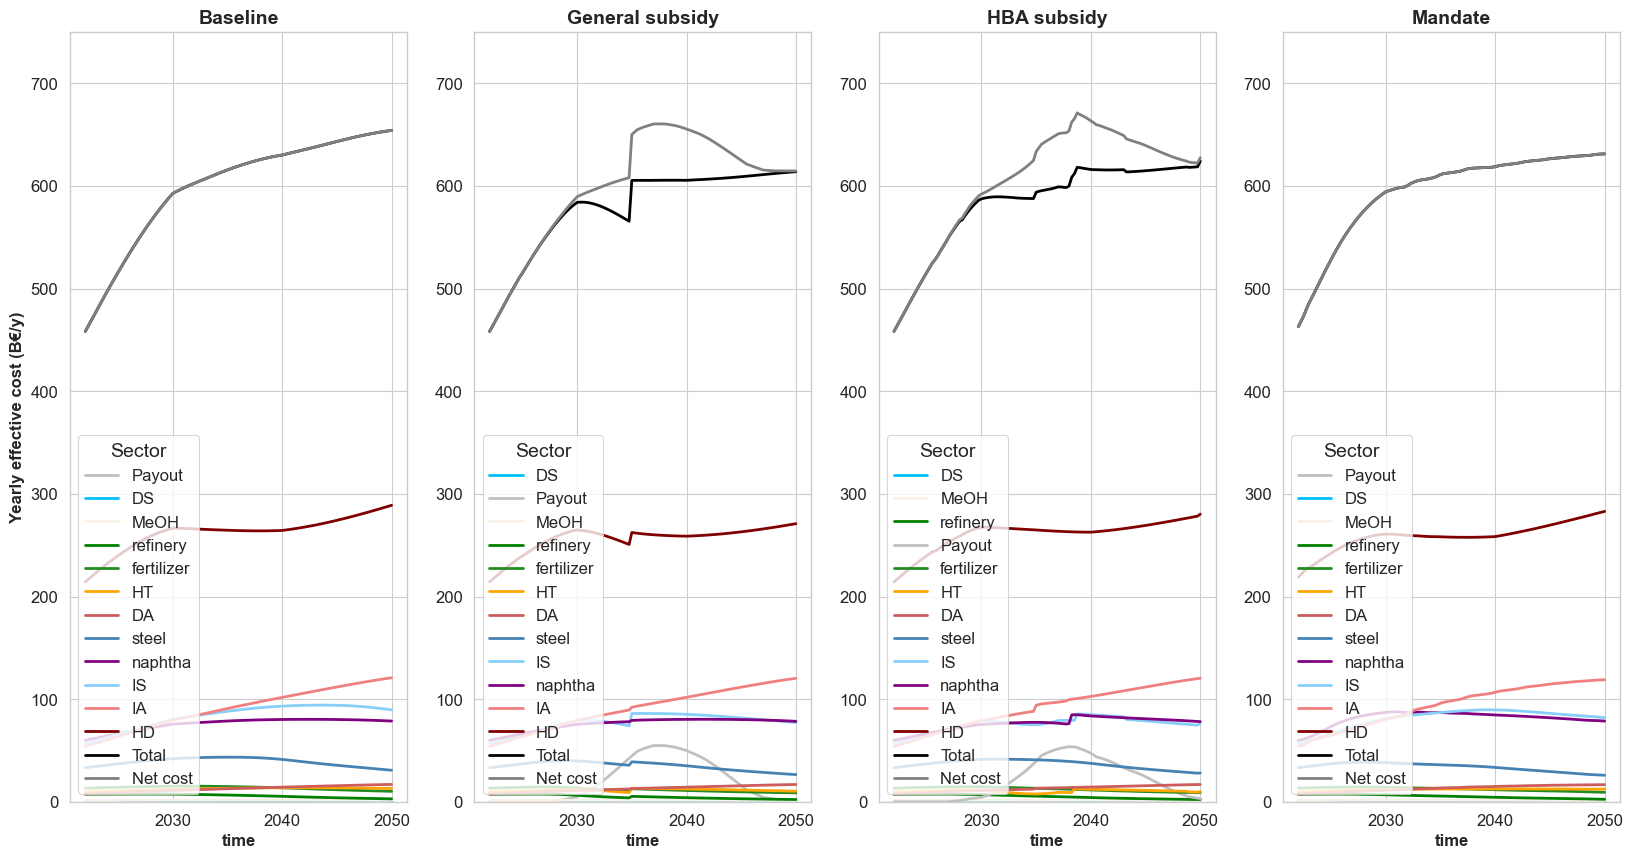

In [71]:
import matplotlib.pyplot as plt

dict_results = {"Baseline": baseline_results,
                "General subsidy": subsidy_results,
                "HBA subsidy": hba_results,
                "Mandate": mandate_results}

dict_color_mapping = {
    "refinery": "green",
    "HT": "orange",
    "fertilizer": "forestgreen",
    "steel": "steelblue",
    "naphtha": "purple",
    "MeOH": "linen",
    "IA": "lightcoral",
    "DA": "indianred",
    "IS": "lightskyblue",
    "DS": "deepskyblue",
    "HD": "maroon",
    "Payout": "silver",
    "Total": "black",
    "Net cost": "gray",
}

def plot_sector_effective_costs(dict_results):
    dict_effective_costs = {}
    sector_effective_costs = ["refinery effective cost",
                                "HT effective cost",
                                "fertilizer effective cost",
                                "steel effective cost",
                                "naphtha effective cost",
                                "MeOH effective cost",
                                "IA effective cost",
                                "DA effective cost",
                                "IS effective cost",
                                "DS effective cost",
                                "HD effective cost",
                                ]
    n_results = len(dict_results)
    baseline_results = dict_results["Baseline"]
    baseline_sector_effective_costs = baseline_results[sector_effective_costs]
    baseline_sector_effective_costs = baseline_sector_effective_costs.rename(columns=lambda x: x.replace(" effective cost", ""))
    fig, axs = plt.subplots(1, n_results, figsize=(5*n_results, 10))
    for key, results in dict_results.items():
        if key != "Baseline":
            results_sector_effective_costs = results[sector_effective_costs]
            results_sector_effective_costs = results_sector_effective_costs.rename(columns=lambda x: x.replace(" effective cost", ""))
            results_sector_effective_costs["Total"] = results_sector_effective_costs.sum(axis=1)
            if key != "Mandate":
                payout = results['hba payout']
            else:
                payout = pd.Series(0, index=results.index)
            results_sector_effective_costs["Payout"] = payout    
            results_sector_effective_costs["Net cost"] = results_sector_effective_costs["Total"] + payout
            dict_effective_costs[key] = results_sector_effective_costs
            ax = axs[list(dict_results.keys()).index(key)]
            results_sector_effective_costs.sort_values(by=results_sector_effective_costs.index[-1], axis=1, inplace=True)
            colors = [dict_color_mapping.get(col,'maroon') for col in results_sector_effective_costs.columns]
            results_sector_effective_costs.plot(ax=ax, legend=False, color=colors, linewidth=2)
        else:
            results_sector_effective_costs = baseline_sector_effective_costs
            results_sector_effective_costs["Total"] = results_sector_effective_costs.sum(axis=1)
            payout = pd.Series(0, index=baseline_results.index)
            results_sector_effective_costs["Payout"] = payout
            results_sector_effective_costs["Net cost"] = results_sector_effective_costs["Total"] + payout
            dict_effective_costs[key] = results_sector_effective_costs
            ax = axs[list(dict_results.keys()).index(key)]
            results_sector_effective_costs.sort_values(by=results_sector_effective_costs.index[-1], axis=1, inplace=True)
            colors = [dict_color_mapping.get(col,'black') for col in results_sector_effective_costs.columns]
            results_sector_effective_costs.plot(ax=ax, legend=False, color=colors, linewidth=2,stacked=False)
        ax.set_title(key)
        ax.set_ylim(0, 750)
    axs[0].legend(title='Sector', loc='lower left')
    axs[1].legend(title='Sector', loc='lower left')
    axs[2].legend(title='Sector', loc='lower left')
    axs[3].legend(title='Sector', loc='lower left')
    axs[0].set_ylabel("Yearly effective cost (B€/y)")
    # axs[1].set_ylabel("Cumulative difference in effective cost (B€)")
    plt.show()
    return dict_effective_costs

dict_effective_costs = plot_sector_effective_costs(dict_results)


In [72]:
## Discounted cashflows
discount_rate = 0.04
def discounted_cashflow(cost_df, discount_rate):
    discounted_df = cost_df.copy()
    for column in cost_df.columns:
        discounted_cost = cost_df[column] / ((1 + discount_rate) ** (cost_df.index - cost_df.index[0]))
        discounted_df[column] = discounted_cost
    return discounted_df

baseline_discounted_costs = discounted_cashflow(dict_effective_costs["Baseline"], discount_rate)
subsidy_discounted_costs = discounted_cashflow(dict_effective_costs["General subsidy"], discount_rate)
hba_discounted_costs = discounted_cashflow(dict_effective_costs["HBA subsidy"], discount_rate)
mandate_discounted_costs = discounted_cashflow(dict_effective_costs["Mandate"], discount_rate)

dict_discounted_costs = {"Baseline": baseline_discounted_costs,
                        "General subsidy": subsidy_discounted_costs,
                        "HBA subsidy": hba_discounted_costs,
                        "Mandate": mandate_discounted_costs}

from python_scripts.result_loading import result_loading_class as rl
sector_subsidy_costs = [tech + " subsidy cost" for tech in rl.h2_tech_to_sector_dict.keys()]

subsidy_sector_subsidy_costs = subsidy_results[sector_subsidy_costs]
hba_sector_subsidy_costs = hba_results[sector_subsidy_costs]

subsidy_sector_subsidy_costs = subsidy_sector_subsidy_costs.rename(columns=lambda x: x.replace(" subsidy cost", ""))
hba_sector_subsidy_costs = hba_sector_subsidy_costs.rename(columns=lambda x: x.replace(" subsidy cost", ""))

subsidy_sector_subsidy_costs["Total"] = subsidy_sector_subsidy_costs.sum(axis=1)
hba_sector_subsidy_costs["Total"] = hba_sector_subsidy_costs.sum(axis=1)

discounted_subsidy = discounted_cashflow(subsidy_sector_subsidy_costs, discount_rate)
discounted_hba = discounted_cashflow(hba_sector_subsidy_costs, discount_rate)


            Baseline  General subsidy  HBA subsidy    Mandate
DA               0.0        -0.070004     0.142527   2.846083
DS               0.0        -5.786620    -2.339436   3.240167
HD               0.0        -1.839066    -0.456145  -1.156102
HT               0.0        -7.653816   -15.026293  -3.414617
IA               0.0        -0.070291     0.142332   2.839628
IS               0.0        -6.021069    -8.104153  -1.991797
MeOH             0.0        -3.689241    -5.017522  -6.576769
Net cost         0.0         0.264288     0.877637  -0.301562
Payout           NaN              inf          inf        NaN
Total            0.0        -2.835569    -2.185676  -0.301562
fertilizer       0.0       -11.871958    -7.310494  -7.226755
naphtha          0.0        -0.037372     0.147708   8.503191
refinery         0.0       -14.152561    -9.350675  -7.958740
steel            0.0        -8.376414    -4.430472 -10.749258


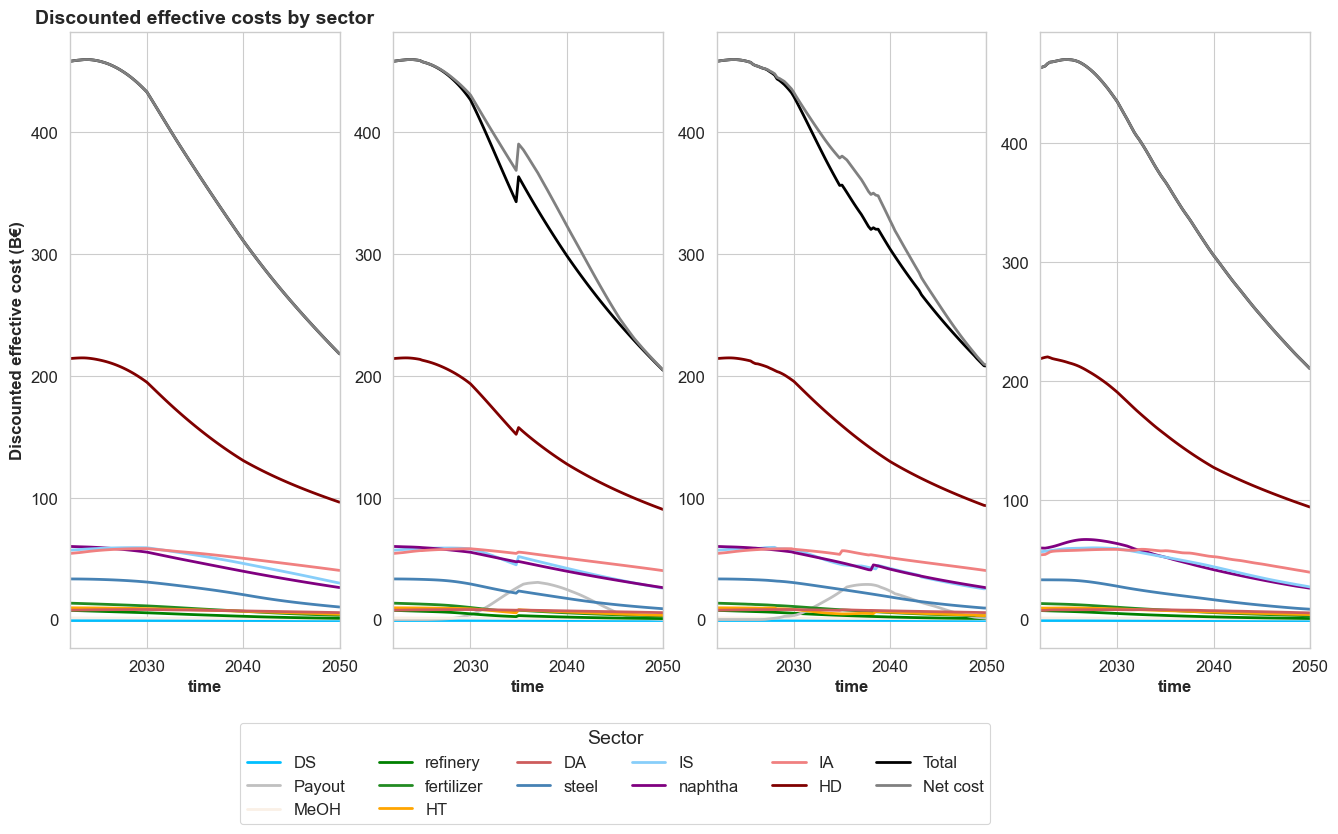

In [73]:
def plot_discounted_costs(dict_discounted_costs):
    fig, ax = plt.subplots(1,len(dict_discounted_costs.items()),figsize=(16,8))
    for i, item in enumerate(dict_discounted_costs.items()):
        discounted_costs = item[1]  # Get the DataFrame from the tuple
        discounted_costs.sort_values(by=discounted_costs.index[-1], axis=1, inplace=True)
        colors = [dict_color_mapping.get(col,'maroon') for col in discounted_costs.columns]
        discounted_costs.plot(ax=ax[i], legend=False, color=colors, linewidth=2)
    ax[0].set_title("Discounted effective costs by sector")
    ax[1].legend(title='Sector', loc='lower left',bbox_to_anchor=(-0.6, -0.3),ncols = 6)
    ax[0].set_ylabel("Discounted effective cost (B€)")
    for ax in ax:
        ax.set_xlim(2022, 2050)
    plt.show()

time_step = dict_results["Baseline"]["TIME STEP"].iloc[0]

baseline_discounted_2050 = baseline_discounted_costs.cumsum().loc[2050] * time_step
subsidy_discounted_2050 = subsidy_discounted_costs.cumsum().loc[2050] * time_step
hba_discounted_2050 = hba_discounted_costs.cumsum().loc[2050] * time_step
mandate_discounted_2050 = mandate_discounted_costs.cumsum().loc[2050] * time_step
all_discounted_2050 = pd.DataFrame({"Baseline": baseline_discounted_2050,
                                    "General subsidy": subsidy_discounted_2050,
                                    "HBA subsidy": hba_discounted_2050,
                                    "Mandate": mandate_discounted_2050})

subsidy_discounted_2050 = discounted_subsidy.cumsum().loc[2050] * time_step
hba_discounted_2050 = discounted_hba.cumsum().loc[2050] * time_step

sector_discounted_subsidies = pd.DataFrame({"Premium": subsidy_discounted_2050, "HBA subsidy": hba_discounted_2050})

all_discounted_2050_relative = all_discounted_2050[all_discounted_2050.columns].div(all_discounted_2050["Baseline"], axis=0) * 100 - 100
all_discounted_2050_difference = all_discounted_2050[all_discounted_2050.columns].sub(all_discounted_2050["Baseline"], axis=0)

# all_discounted_2050.to_csv("vensim_results\\all_discounted_2050.csv")
print(all_discounted_2050_relative)
# print(all_discounted_2050)
# print(sector_discounted_subsidies)

plot_discounted_costs(dict_discounted_costs)

### H2 cost - learning

Unsubsidized 2050 unsubsidized green H2 cost: 1.76 €/kgH2
Premium 2050 unsubsidized green H2 cost: 2.28 €/kgH2
Auction 2050 unsubsidized green H2 cost: 2.31 €/kgH2
Mandate 2050 unsubsidized green H2 cost: 2.32 €/kgH2


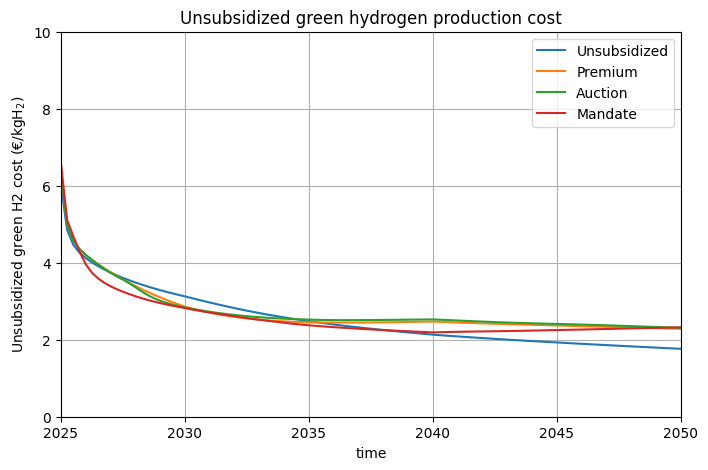

In [5]:
import matplotlib.pyplot as plt
dict_solutions = {"Unsubsidized": baseline_results,
                  "Premium": subsidy_results,
                    "Auction": hba_results,
                    "Mandate": mandate_results}
keys = list(dict_solutions.keys())

dict_h2_prod_costs = {}
for key, results in dict_solutions.items():
    h2_prod_cost = results['Unsubsidized green H2 cost']
    dict_h2_prod_costs[key] = h2_prod_cost

fig, ax = plt.subplots(figsize=(8,5))
for key in dict_h2_prod_costs:
    dict_h2_prod_costs[key].plot(ax=ax, label=key)
    print(f"{key} 2050 unsubsidized green H2 cost: {dict_h2_prod_costs[key].loc[2050]:.2f} €/kgH2")
ax.set_title("Unsubsidized green hydrogen production cost")
ax.set_ylabel("Unsubsidized green H2 cost (€/kgH$_{2}$)")
ax.legend()
ax.set_ylim(0, 10)
ax.set_xlim(2025, 2050)
ax.grid(True)
plt.show()


Unsubsidized 337.8163456463407
Premium 279.5617044571523
Auction 292.8531988638516
Mandate 288.9292494357172


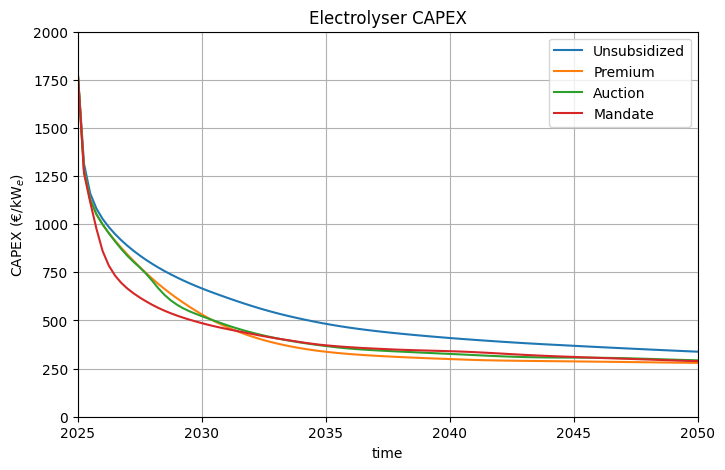

In [6]:
import matplotlib.pyplot as plt
dict_solutions = {"Unsubsidized": baseline_results,
                  "Premium": subsidy_results,
                    "Auction": hba_results,
                    "Mandate": mandate_results}
keys = list(dict_solutions.keys())

dict_h2_CAPEX = {}
for key, results in dict_solutions.items():
    h2_CAPEX = results['AEC CAPEX']
    dict_h2_CAPEX[key] = h2_CAPEX

fig, ax = plt.subplots(figsize=(8,5))
for key in dict_h2_CAPEX:
    dict_h2_CAPEX[key].plot(ax=ax, label=key)
    print(key, dict_h2_CAPEX[key].iloc[-1])
ax.set_title("Electrolyser CAPEX")
ax.set_ylabel("CAPEX (€/kW$_e$)")
ax.legend()
ax.set_ylim(0, 2000)
ax.set_xlim(2025, 2050)
ax.grid(True)
plt.show()


### Test with sectors disallowed for subsidy

In [100]:
hba_model_noHD = baseline_model.copy()
hba_model_noHD.set_components({"HBA": 1})
hba_model_noHD.set_components({"HBA budget plan": df_budget, "bid increase" : 1, "HBA duration": 25, "HBA max subsidy": 10,"HT subsidy ban": 1})

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1123: UserWarning: Replacing a constant value with a time-dependent value. The value will be interpolated over time.
  warnings.warn(
c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1145: UserWarning: Replacing a variable by a constant value.
  warnings.warn("Replacing a variable by a constant value.")


In [101]:
def real_hba_auction():
    hba = hba_model_noHD.components.hba()
    budget = hba_model_noHD.components.hba_budget()
    max_subsidy = hba_model_noHD.components.hba_max_subsidy()
    if bool(hba):
        bids = [] # For each technology we build a list entry: ("tech_name", volume, ask_price)
        bid_increaser = hba_model_noHD.components.bid_increase()        
        for tech, sub_sector in rl.h2_tech_to_sector_dict.items():
            ask_price   = hba_model_noHD.components.__getattribute__(tech.replace(" ", "_").lower() + "_h2_wtp_gap")() # €/kg H2 subsidy ask
            if bid_increaser > 1:
                ask_price = max(min(ask_price + bid_increaser, max_subsidy), ask_price) # Increase bid price according to bid increaser but cap at max subsidy
            vol         = hba_model_noHD.components.__getattribute__(tech.replace(" ", "_").lower() + "_hba_volume")() # t H2/yr investment bid
            ask_period  = rl.sector_to_lifetime.get(sub_sector, 10) # years of support asked for
            ask_funding = (ask_price > 0) * ask_price * vol * ask_period * 1000 * 1e-9 # Units are €/kg * t/yr * yr * kg/t * B€/€ = B€
            bids.append([tech, ask_funding, ask_price])
        sorted_bids = sorted(bids, key=lambda bid: bid[2])
        sorted_funding = np.asarray(sorted_bids)[:,1].astype(float)
        sorted_asks = np.asarray(sorted_bids)[:,2].astype(float)
        cum_funding = np.cumsum(sorted_funding)
        clearing_ix = sum(cum_funding < budget)-1
        highest_accepted_ask = sorted_asks[max(clearing_ix, 0)] if clearing_ix>=0 else 0 # The last ask within budget is the highest accepted.
        return min(highest_accepted_ask,max_subsidy) # Cap of 3.5 https://www.spglobal.com/commodity-insights/en/news-research/latest-news/energy-transition/043024-eus-hydrogen-bank-auction-clears-below-50-euro-centkg-funding-15-gw
    else:
        return 0
hba_model_noHD.components.hba_auction = real_hba_auction # Define the auction logic

In [102]:
def bid_increase_function():
    time_step = hba_model_noHD.components.time_step()
    alpha = max(min(1, 1 - 4 * time_step), 0) # Smoothing factor for bid increase adjustment
    allocated = hba_model_noHD.components.allocated_money_previous()
    budget = hba_model_noHD.components.hba_budget_previous()
    previous_bid_increase = hba_model_noHD.components.bid_increase_previous()
    new_bid_increase = 1
    if allocated > 0 and budget > 0:
        new_bid_increase = max(1, np.sqrt(budget / allocated))
    return alpha * previous_bid_increase + (1 - alpha) * new_bid_increase
hba_model_noHD.components.bid_increase = bid_increase_function

c:\GitHub\h2_system_dynamics_paper\.venv\Lib\site-packages\pysd\py_backend\model.py:1133: UserWarning: Replacing a constant value with a callable. The value may not be constant anymore.
  warnings.warn(


In [103]:
final_year = 2050
hba_model_noHD.components.hba_auction = real_hba_auction # Define the auction logic
hba_model_noHD_results = hba_model_noHD.run(final_time=final_year)

In [104]:
sd_plot.plot_sector_costs(model_results=hba_model_noHD_results,
                          model=hba_model_noHD,
                          filename="Sector cost HBA subsidy ban heavy duty")

sd_plot.plot_sector_production(model_results=hba_model_noHD_results,
                               filename="Sector production HBA subsidy ban heavy duty")

hba_yearly_noHD, hba_noHD_emissions = sd_plot.plot_system_emissions(model_results=hba_model_noHD_results,
                                                filename="Sector emissions HBA subsidy ban heavy duty",
                                                write_df=True,
                                                cumulative_emissions=False)

sd_plot.plot_hydrogen_projection(hba_model_noHD_results,
                                 filename="Hydrogen projection HBA subsidy ban heavy duty",
                                 step_horizontal_lines=200,)

Figure saved at results/Sector cost HBA subsidy ban heavy duty_industry.png
Figure saved at results/Sector cost HBA subsidy ban heavy duty_transport.png
Figure saved at results/Sector production HBA subsidy ban heavy duty_industry.png
Figure saved at results/Sector production HBA subsidy ban heavy duty_transport.png
Figure saved at results/Sector emissions HBA subsidy ban heavy duty.png
Figure saved at results/Hydrogen projection HBA subsidy ban heavy duty.png


In [105]:
cost_hba_noHD = np.sum(hba_model_noHD_results['hba payout'] * time_step)
hba_noHD_cumulative_emissions = hba_noHD_emissions.loc[2050].sum()
hba_noHD_emission_difference = hba_noHD_cumulative_emissions - base_cumulative_emissions

hba_noHD_abatement_cost = cost_hba_noHD / -hba_noHD_emission_difference
print("Standard HBA cost: ",cost_hba_subsidy)
print("HBA subsidy ban heavy duty cost",cost_hba_noHD)
print("Standard HBA abatement cost (€/ton CO2): ", hba_abatement_cost)
print("HBA subsidy ban heavy duty abatement cost (€/ton CO2): ", hba_noHD_abatement_cost)
print("Standard HBA emission reduction (Gt CO2): ", hba_emission_difference)
print("HBA subsidy ban heavy duty emission reduction (Gt CO2): ", hba_noHD_emission_difference)

Standard HBA cost:  614.7046822421332
HBA subsidy ban heavy duty cost 608.704394798854
Standard HBA abatement cost (€/ton CO2):  254.69712726780836
HBA subsidy ban heavy duty abatement cost (€/ton CO2):  257.7426348195386
Standard HBA emission reduction (Gt CO2):  -2.413473166486817
HBA subsidy ban heavy duty emission reduction (Gt CO2):  -2.3616752239110355


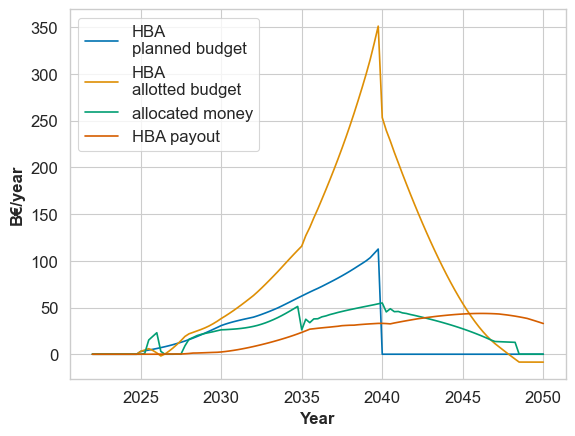

Total budget:  706.2078328645116 B€
Excess payouts: -97.50343806565763 B€


In [107]:
hba_model_noHD_results['HBA budget plan'].plot(label="HBA\nplanned budget")
hba_model_noHD_results['HBA budget'].plot(label="HBA\nallotted budget")
hba_model_noHD_results['allocated money'].plot()
hba_model_noHD_results['hba payout'].plot(label="HBA payout")
plt.ylabel("B€/year")
plt.xlabel("Year")
# plt.xlim(2025,2028)
# plt.ylim(0,200)
plt.legend()
plt.show()
print("Total budget: ", np.sum(hba_model_noHD_results['HBA budget plan'] * hba_model_noHD_results["TIME STEP"].iloc[0]), "B€")
print("Excess payouts:", np.sum(hba_model_noHD_results['hba payout'] - hba_model_noHD_results['HBA budget plan']) * hba_model_noHD_results["TIME STEP"].iloc[0], "B€")

### some extra plots

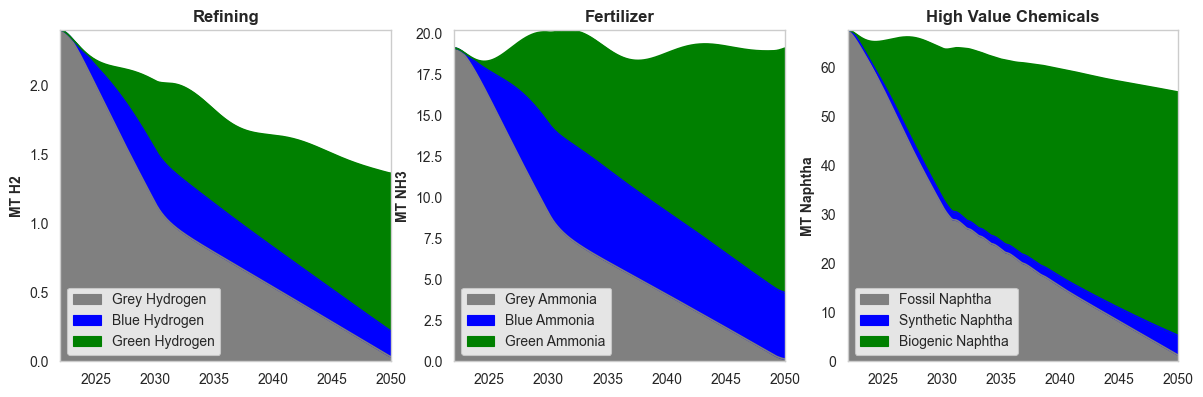

In [82]:
model_results = mandate_results

main_sector = "industry"
sub_sectors = ["refinery", "fertilizer", "naphtha"]
counter = 0

fig, axs = plt.subplots(1, 3, figsize=(12, 4))
fig.tight_layout(h_pad=2.0, w_pad=1.0)  # Add padding between subplots
for i, (sub_sector, sub_dict) in enumerate(rl.sector_dict[main_sector].items()):
    if sub_sector in sub_sectors:
        if sub_dict["unit"] == "GWh":
            unit = "TWh"
            df = model_results[sub_dict["stocks"]] / 1000
        else:
            unit = sub_dict["unit"]
            df = model_results[sub_dict["stocks"]]
        df.index = model_results.index
        df.columns = list(map(lambda x: rl.pretty_names_technologies[x], df.columns ))
        # ax = axs[i%2, i//2]
        ax = axs[counter]
        df.plot.area(ax=ax, color=["gray", "blue", "green", "lightblue"])
        ax.title.set_text(rl.pretty_names[sub_sector])
        ax.title.set_fontsize(12)
        ax.title.set_fontweight('bold')
        ax.set_xlabel("")
        ax.set_ylabel(unit)
        # Reduce the font size of the axis labels
        ax.xaxis.label.set_fontsize(10)
        ax.xaxis.label.set_fontweight('bold')
        ax.yaxis.label.set_fontsize(10)
        # Reduce the size of the tick labels
        ax.tick_params(axis='both', which='major', labelsize=10)
        # Reduce the size of the legend
        ax.legend(loc='lower left', fontsize=10)
        ax.grid(False)
        
        ax.autoscale(enable=True, axis='both', tight=True)  # Adjust the axis limits to fit the data
        counter += 1

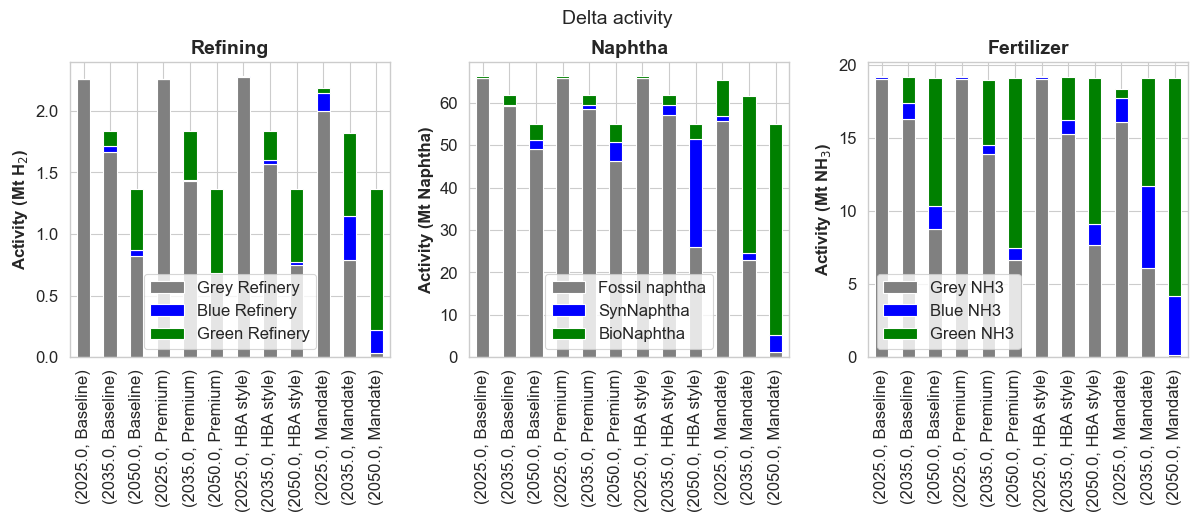

In [147]:
result_dictionary = {"baseline": baseline_results,
                     "subsidy": subsidy_results,
                     "hba": hba_results,
                     "mandate": mandate_results,
                     }

def plot_figure_1_for_claire(model_results_dictionary = dict) -> None:
    keys = list(model_results_dictionary.keys())
    refining_sector = ["Grey Refinery", "Blue Refinery", "Green Refinery"]
    hvc_sector = ["Fossil naphtha", "SynNaphtha", "BioNaphtha"]
    fertilizer_sector = ["Grey NH3", "Blue NH3", "Green NH3"]
    
    base_results = model_results_dictionary[keys[0]]
    subsidy_results = model_results_dictionary[keys[1]]
    hba_results = model_results_dictionary[keys[2]]
    mandate_results = model_results_dictionary[keys[3]]

    base = base_results[refining_sector+hvc_sector+fertilizer_sector].reset_index()
    # base["Year"] = base.index
    base = base[base["time"].isin([2025,2035,2050])].reset_index(drop=True)
    base["Scenario"] = "Baseline"
    # base.set_index(["Year","Scenario"], inplace=True)
    subsidy = subsidy_results[refining_sector+hvc_sector+fertilizer_sector].reset_index()
    # subsidy["Year"] = subsidy.index
    subsidy = subsidy[subsidy["time"].isin([2025,2035,2050])].reset_index(drop=True)
    subsidy["Scenario"] = "Premium"
    # subsidy.set_index(["Year","Scenario"], inplace=True)
    hba = hba_results[refining_sector+hvc_sector+fertilizer_sector].reset_index()
    # hba["Year"] = hba_results.index
    hba = hba[hba["time"].isin([2025,2035,2050])].reset_index(drop=True)
    hba["Scenario"] = "HBA style"
    # hba.set_index(["Year","Scenario"], inplace=True)
    mandate = mandate_results[refining_sector+hvc_sector+fertilizer_sector].reset_index()
    # mandate["Year"] = mandate_results.index
    mandate = mandate[mandate["time"].isin([2025,2035,2050])].reset_index(drop=True)
    mandate["Scenario"] = "Mandate"
    # mandate.set_index(["Year","Scenario"], inplace=True)

    absolute_activity = pd.concat([base, subsidy, hba, mandate], axis=0)
    delta_activity = absolute_activity.copy()
    delta_activity.loc[delta_activity["Scenario"]=="Baseline", refining_sector+hvc_sector+fertilizer_sector] = 0
    delta_activity.loc[delta_activity["Scenario"]=="Premium", refining_sector+hvc_sector+fertilizer_sector] = delta_activity.loc[delta_activity["Scenario"]=="Premium", refining_sector+hvc_sector+fertilizer_sector].values - absolute_activity.loc[absolute_activity["Scenario"]=="Baseline", refining_sector+hvc_sector+fertilizer_sector].values
    delta_activity.loc[delta_activity["Scenario"]=="HBA style", refining_sector+hvc_sector+fertilizer_sector] = delta_activity.loc[delta_activity["Scenario"]=="HBA style", refining_sector+hvc_sector+fertilizer_sector].values - absolute_activity.loc[absolute_activity["Scenario"]=="Baseline", refining_sector+hvc_sector+fertilizer_sector].values
    delta_activity.loc[delta_activity["Scenario"]=="Mandate", refining_sector+hvc_sector+fertilizer_sector] = delta_activity.loc[delta_activity["Scenario"]=="Mandate", refining_sector+hvc_sector+fertilizer_sector].values - absolute_activity.loc[absolute_activity["Scenario"]=="Baseline", refining_sector+hvc_sector+fertilizer_sector].values


    absolute_activity.set_index(["time","Scenario"], inplace=True)
    # delta_activity = delta_activity[delta_activity["Scenario"] != "Baseline"]
    delta_activity.set_index(["time","Scenario"], inplace=True)

    df_plot = absolute_activity.copy()
    df_refinery = df_plot[refining_sector]
    df_hvc =  df_plot[hvc_sector]
    df_fertilizer  = df_plot[fertilizer_sector]

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    fig.tight_layout(h_pad=2.0, w_pad=2.0)
    df_refinery.plot(kind='bar', stacked=True, ax=axs[0], color=["gray", "blue", "green"])
    axs[0].set_title("Refining")
    axs[0].set_xlabel("")
    axs[0].set_ylabel("Activity (Mt H$_2$)")
    df_hvc.plot(kind='bar', stacked=True, ax=axs[1], color=["gray", "blue", "green"])
    axs[1].set_title("Naphtha")
    axs[1].set_xlabel("")
    axs[1].set_ylabel("Activity (Mt Naphtha)")
    df_fertilizer.plot(kind='bar', stacked=True, ax=axs[2], color=["gray", "blue", "green"])
    axs[2].set_title("Fertilizer")
    axs[2].set_xlabel("")
    axs[2].set_ylabel("Activity (Mt NH$_3$)")

    fig.suptitle("Delta activity", fontsize=14)
    fig.subplots_adjust(top=0.85)
    return None

plot_figure_1_for_claire(result_dictionary)


### Write incfiles

In [8]:
import python_scripts.write_functions as sd_write
dl = data_loading_class()
distribution_keys = dl.load_distribution_keys()
electricity_demand = dl.load_electricity_demand()
hydrogen_data = dl.load_hydrogen_data()
model_years = [2030, 2040, 2050]

sosibu_baseline = sd_write.write_fuel_demand(model_results=baseline_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        filename="SOSIBUBOUND",
                                        )
sosibu_sub = sd_write.write_fuel_demand(model_results=subsidy_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        filename="SOSIBUBOUND",
                                        sub_path="_subsidy"
                                        )
sosibu_hba = sd_write.write_fuel_demand(model_results=hba_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        filename="SOSIBUBOUND",
                                        sub_path="_hba"
                                        )
sosibu_mandate = sd_write.write_fuel_demand(model_results=mandate_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        filename="SOSIBUBOUND",
                                        sub_path="_mandate"
                                        )

dh2_baseline = sd_write.write_hydrogen_demand(model_results=baseline_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        )
dh2_sub = sd_write.write_hydrogen_demand(model_results=subsidy_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        sub_path="_subsidy"
                                        )
dh2_hba = sd_write.write_hydrogen_demand(model_results=hba_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        sub_path="_hba"
                                        )
dh2_mandate = sd_write.write_hydrogen_demand(model_results=mandate_results,
                                        distribution_keys=distribution_keys,
                                        model_years=[2030, 2040, 2050],
                                        sub_path="_mandate"
                                        )

de_trans_baseline, de_total_baseline = sd_write.write_electricity_demand(model_results=baseline_results,
                                            distribution_keys=distribution_keys,
                                            electricity_demand=electricity_demand,
                                            model_years=[2030, 2040, 2050],
                                            )
de_trans_sub, de_total_sub = sd_write.write_electricity_demand(model_results=subsidy_results,
                                            distribution_keys=distribution_keys,
                                            electricity_demand=electricity_demand,
                                            model_years=[2030, 2040, 2050],
                                            sub_path="_subsidy"
                                            )
de_trans_hba, de_total_hba = sd_write.write_electricity_demand(model_results=hba_results,
                                            distribution_keys=distribution_keys,
                                            electricity_demand=electricity_demand,
                                            model_years=[2030, 2040, 2050],
                                            sub_path="_hba"
                                            )
de_trans_mandate, de_total_mandate = sd_write.write_electricity_demand(model_results=mandate_results,
                                            distribution_keys=distribution_keys,
                                            electricity_demand=electricity_demand,
                                            model_years=[2030, 2040, 2050],
                                            sub_path="_mandate"
                                            )

electrolyzer_CAPEX_baseline = sd_write.write_electrolyzer_capex(model_results=baseline_results,
                                                        hydrogen_data=hydrogen_data,
                                                        model_years=model_years
                                                        )
electrolyzer_CAPEX_sub = sd_write.write_electrolyzer_capex(model_results=subsidy_results,
                                                        hydrogen_data=hydrogen_data,
                                                        model_years=model_years,
                                                        sub_path="_subsidy"
                                                        )
electrolyzer_CAPEX_hba = sd_write.write_electrolyzer_capex(model_results=hba_results,
                                                        hydrogen_data=hydrogen_data,
                                                        model_years=model_years,
                                                        sub_path="_hba"
                                                        )
electrolyzer_CAPEX_mandate = sd_write.write_electrolyzer_capex(model_results=mandate_results,
                                                        hydrogen_data=hydrogen_data,
                                                        model_years=model_years,
                                                        sub_path="_mandate"
                                                        )

c:\GitHub\h2_system_dynamics_paper\python_scripts\write_functions.py:588: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  hydrogen_data.fillna('', inplace=True)
